csv https://docs.google.com/spreadsheets/d/18gknYCB8Zzc8MPUXeHAgtiwa761QuVi7YusojtWaba0/edit?usp=sharing

In [29]:
from pathlib import Path
import pandas as pd
import numpy as np

ROOT = Path.cwd()  # notebook working dir: package_metadata
BASE = ROOT / "openml"
if not BASE.exists():
    BASE = ROOT.parent / "openml"  # fallback to project-root/openml
assert BASE.exists(), f"BASE not found: {BASE}"

METRIC_COLS = ["mae", "top_k", "explanation_time", "mmd", "compression_time"]
GROUP_COLS = ["size", "explainer", "strategy", "method",
              "kernel", "data_modification_method", "model"]


def lower_power_of_two(v):
    """Snap v to nearest lower power of 2 (keep if already power of 2)."""
    try:
        n = int(v)
    except (TypeError, ValueError):
        return np.nan if pd.isna(v) else v
    if n <= 0:
        return n
    # integer-safe power-of-two snap
    return 1 << (n.bit_length() - 1)


def build_avg_tables():
    for ds_dir in [p for p in BASE.iterdir() if p.is_dir()]:
        csv_paths = list(ds_dir.glob("*/*.csv"))
        print(f"{ds_dir.name}: found {len(csv_paths)} csv files")
        if not csv_paths:
            continue

        dfs = []
        for path in csv_paths:
            if path.stat().st_size == 0:
                print(f"Skip empty file: {path}")
                continue
            try:
                df = pd.read_csv(path)
            except pd.errors.EmptyDataError:
                print(f"Skip unreadable file: {path}")
                continue

            # derive model tag from filename
            lower_path = path.name.lower()
            model_tag = ""
            if "ann" in lower_path:
                model_tag = "nn"
            elif "xgboost" in lower_path:
                model_tag = "xgb"
            df["model"] = model_tag

            if "mae" not in df.columns and "ae" in df.columns:
                df = df.rename(columns={"ae": "mae"})

            dfs.append(df)

        if not dfs:
            print(f"No valid CSVs in {ds_dir}")
            continue

        data = pd.concat(dfs, ignore_index=True)

        # keep only needed columns
        cols_needed = GROUP_COLS + METRIC_COLS
        data = data[[c for c in cols_needed if c in data.columns]].copy()

        # coerce metrics
        for col in METRIC_COLS:
            if col in data.columns:
                data[col] = pd.to_numeric(data[col], errors="coerce")

        # snap size to nearest lower power of 2
        if "size" in data.columns:
            data["size"] = data["size"].apply(lower_power_of_two)

        group_by = [c for c in GROUP_COLS if c in data.columns]
        metric_cols = [c for c in METRIC_COLS if c in data.columns]

        avg = (
            data.groupby(group_by, dropna=False)[metric_cols]
            .mean()
            .reset_index()
        )

        out_path = ds_dir / "avg_metrics_new.csv"
        avg.to_csv(out_path, index=False)
        print(f"Wrote {out_path}")


def build_summary_and_ranks():
    METRIC_COLS_SUMMARY = ["mae", "mmd", "top_k", "explanation_time", "compression_time"]

    # Read all avg_metrics_new.csv files
    all_data = []
    for ds_dir in [p for p in BASE.iterdir() if p.is_dir()]:
        avg_file = ds_dir / "avg_metrics_new.csv"
        if not avg_file.exists():
            continue
        df = pd.read_csv(avg_file)
        df["dataset"] = ds_dir.name
        all_data.append(df)

    if not all_data:
        print("No avg_metrics_new.csv files found")
        return

    combined = pd.concat(all_data, ignore_index=True)

    # snap size again (ensures consistency even after reload)
    if "size" in combined.columns:
        combined["size"] = combined["size"].apply(lower_power_of_two)

    # ensure kernel column exists
    if "kernel" not in combined.columns:
        combined["kernel"] = np.nan

    # build col_level
    combined["col_level"] = combined["kernel"]

    if "data_modification_method" in combined.columns and "method" in combined.columns:
        kernel_missing = (
            combined["kernel"].isna()
            | combined["kernel"].astype(str).str.strip().str.lower().isin(["not needed", "na", "nan", ""])
        )
        kt_mask = (combined["method"] == "kernel_thinning") & kernel_missing
        dm_mask = kt_mask & combined["data_modification_method"].notna()

        # IMPORTANT: align indexes on both sides
        combined.loc[dm_mask, "col_level"] = combined.loc[dm_mask, "data_modification_method"]

    # pivot
    idx = [c for c in ["dataset", "size", "model", "explainer", "strategy"] if c in combined.columns]
    pivot = combined.pivot_table(
        index=idx,
        columns=["method", "col_level"],
        values=[c for c in METRIC_COLS_SUMMARY if c in combined.columns],
        aggfunc="mean",
    )

    # flatten columns
    pivot.columns = ["_".join(map(str, col)).strip() for col in pivot.columns]
    pivot.reset_index(inplace=True)

    # save unranked summary
    out_summary = ROOT / "summary_table.csv"
    pivot.to_csv(out_summary, index=False)
    print(f"Wrote {out_summary}")

    # ---- ranks ----
    ranked = pivot.copy()

    # mae, mmd, times: lower is better (rank 1 = lowest)
    for prefix in ["mae_", "mmd_", "explanation_time_", "compression_time_"]:
        cols = [c for c in ranked.columns if c.startswith(prefix)]
        if cols:
            ranked[cols] = ranked[cols].rank(axis=1, method="dense", ascending=True)

    # top_k: higher is better (rank 1 = highest)
    topk_cols = [c for c in ranked.columns if c.startswith("top_k_")]
    if topk_cols:
        ranked[topk_cols] = ranked[topk_cols].rank(axis=1, method="dense", ascending=False)

    out_ranked = ROOT / "summary_table_ranked.csv"
    ranked.to_csv(out_ranked, index=False)
    print(f"Wrote {out_ranked}")


build_avg_tables()
build_summary_and_ranks()


nomao: found 5 csv files
Wrote /Users/milannapahasian_user_account/Documents/UNI/CTE_thesis/bsc-compress-then-explain/bsc-compress-then-explain/package_metadata/openml/nomao/avg_metrics_new.csv
wilt: found 30 csv files
Wrote /Users/milannapahasian_user_account/Documents/UNI/CTE_thesis/bsc-compress-then-explain/bsc-compress-then-explain/package_metadata/openml/wilt/avg_metrics_new.csv
isolet: found 4 csv files
Wrote /Users/milannapahasian_user_account/Documents/UNI/CTE_thesis/bsc-compress-then-explain/bsc-compress-then-explain/package_metadata/openml/isolet/avg_metrics_new.csv
white_wine: found 24 csv files
Wrote /Users/milannapahasian_user_account/Documents/UNI/CTE_thesis/bsc-compress-then-explain/bsc-compress-then-explain/package_metadata/openml/white_wine/avg_metrics_new.csv
wave_energy: found 4 csv files
Wrote /Users/milannapahasian_user_account/Documents/UNI/CTE_thesis/bsc-compress-then-explain/bsc-compress-then-explain/package_metadata/openml/wave_energy/avg_metrics_new.csv
pumady

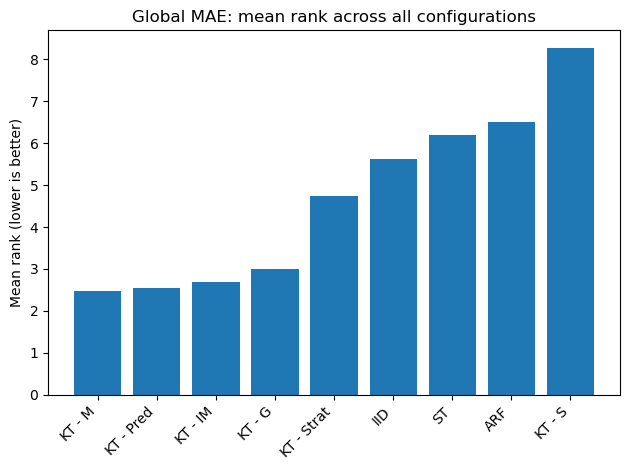

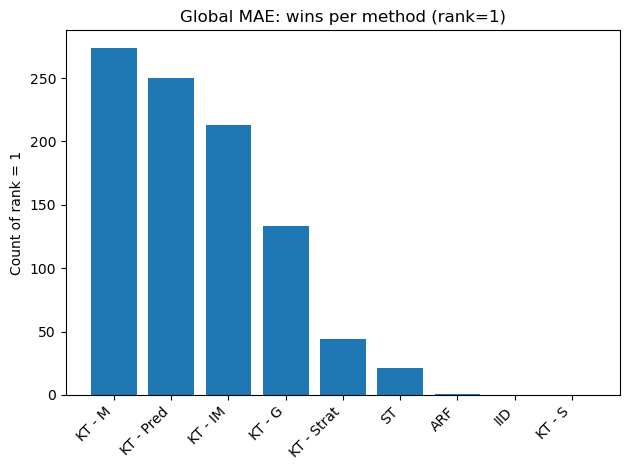

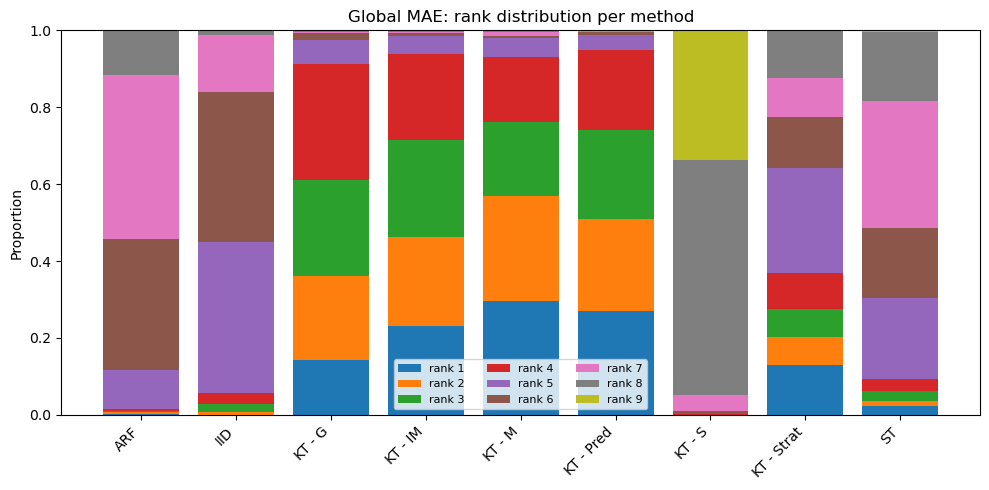

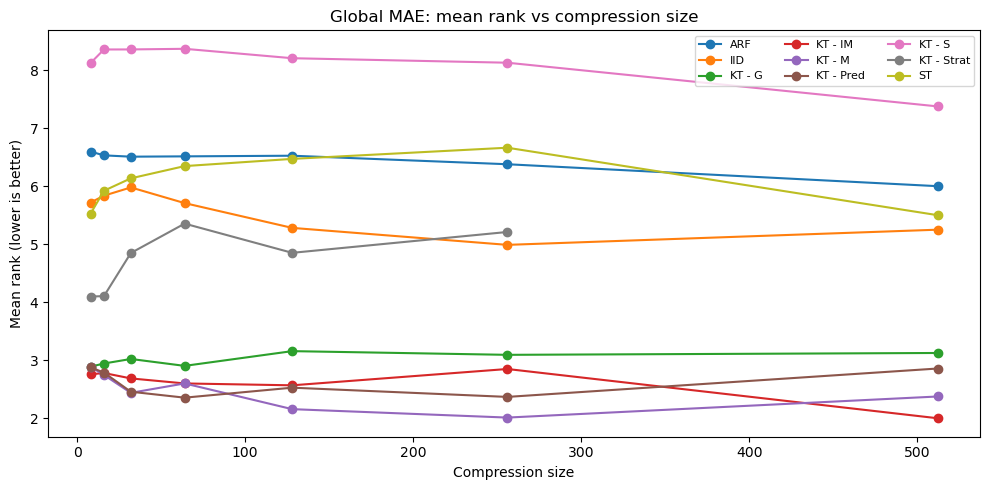

/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_41974/2277959262.py:173: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heat = sub.groupby(["feature_bin", "method"])["rank"].mean().unstack()


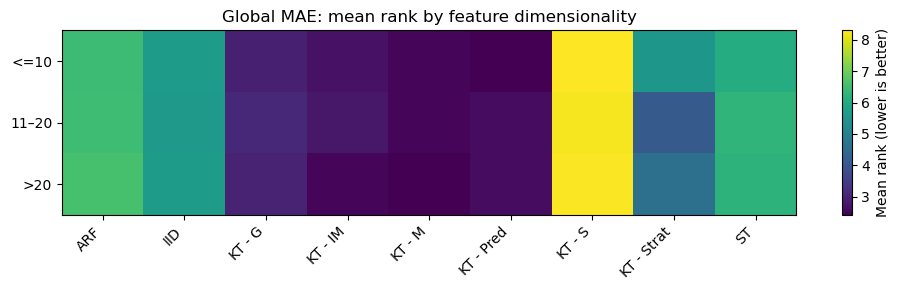

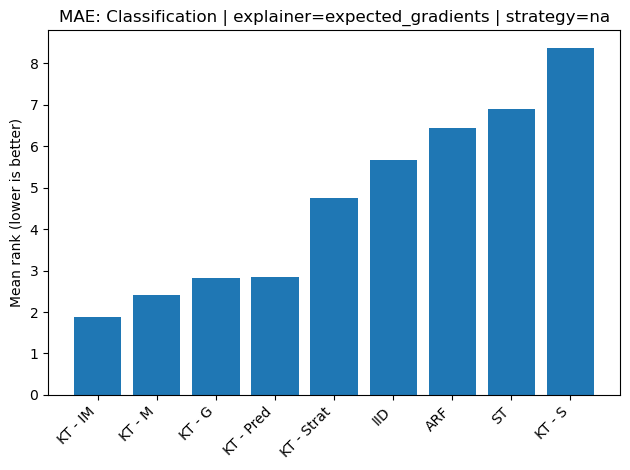

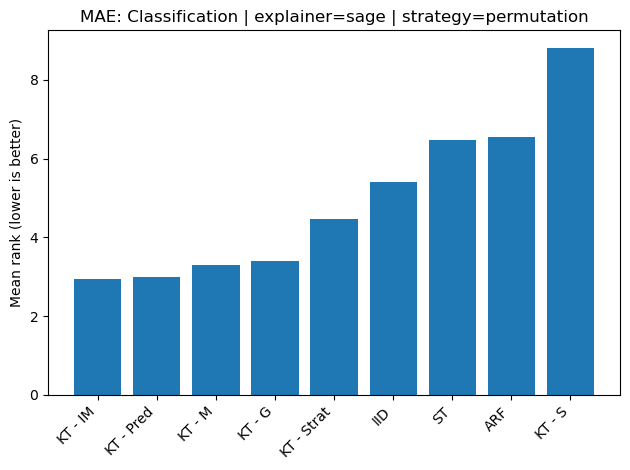

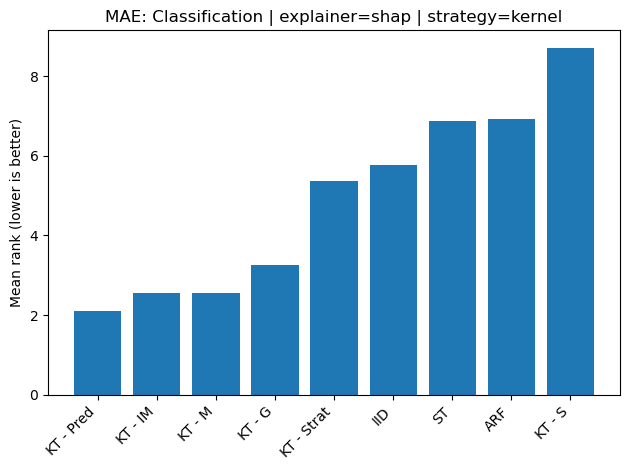

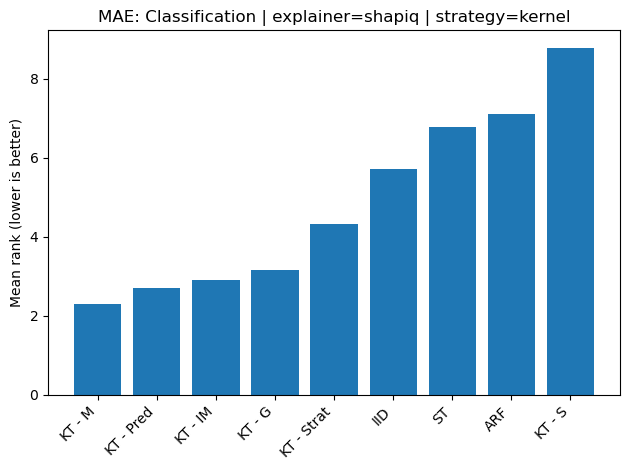

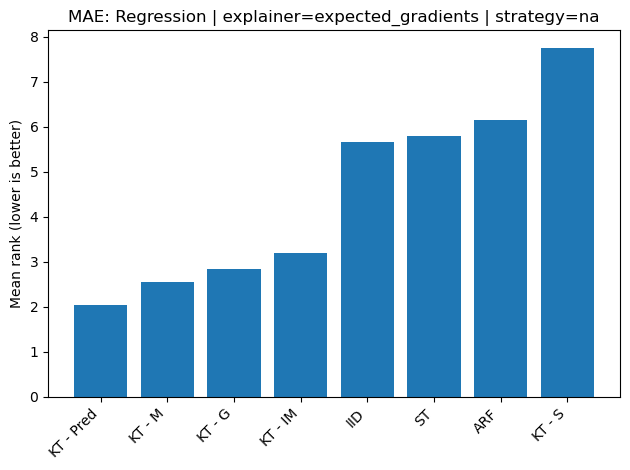

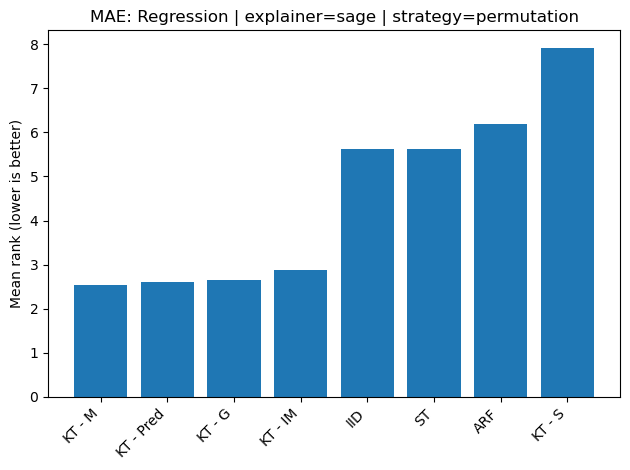

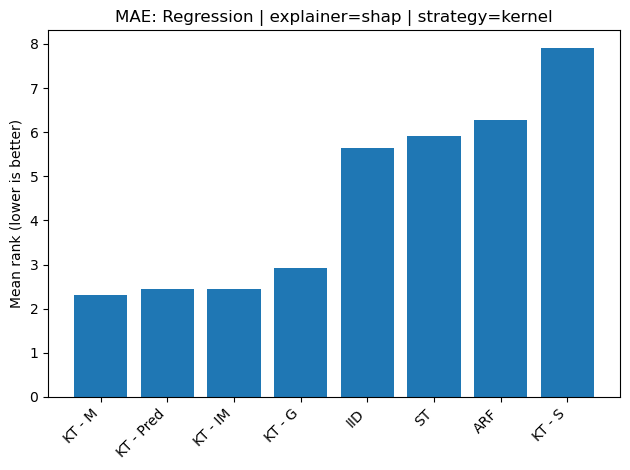

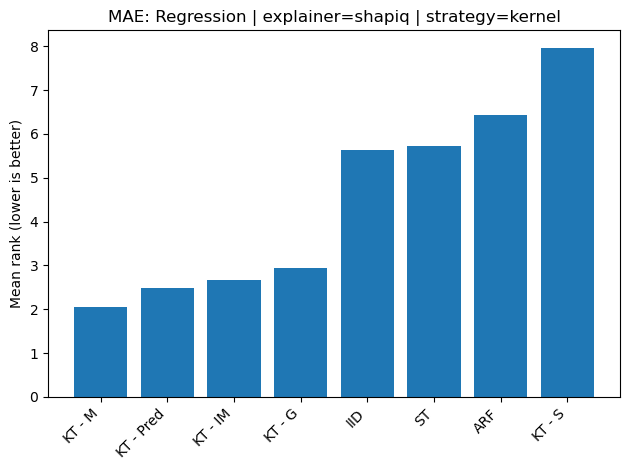

/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_41974/2277959262.py:173: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heat = sub.groupby(["feature_bin", "method"])["rank"].mean().unstack()


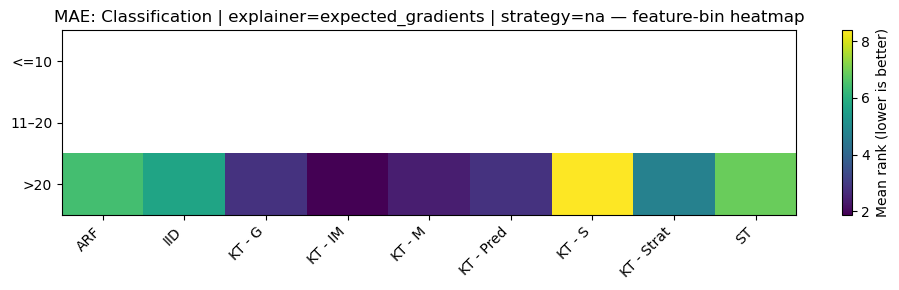

/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_41974/2277959262.py:173: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heat = sub.groupby(["feature_bin", "method"])["rank"].mean().unstack()


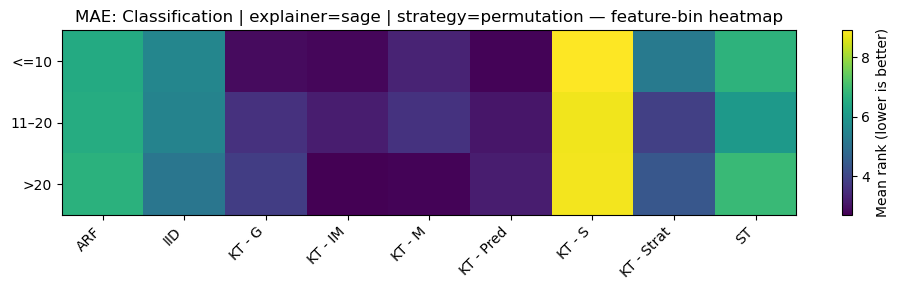

/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_41974/2277959262.py:173: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heat = sub.groupby(["feature_bin", "method"])["rank"].mean().unstack()


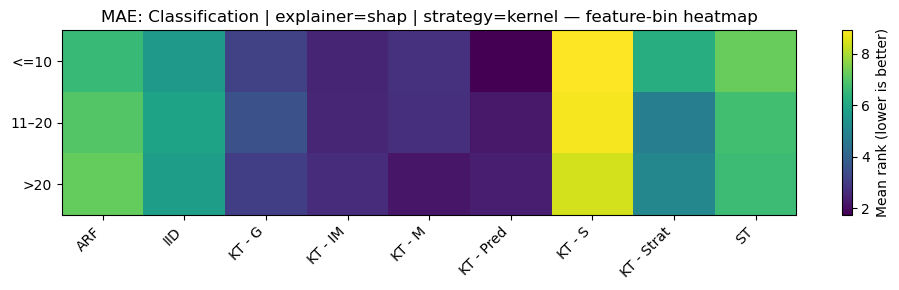

/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_41974/2277959262.py:173: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heat = sub.groupby(["feature_bin", "method"])["rank"].mean().unstack()


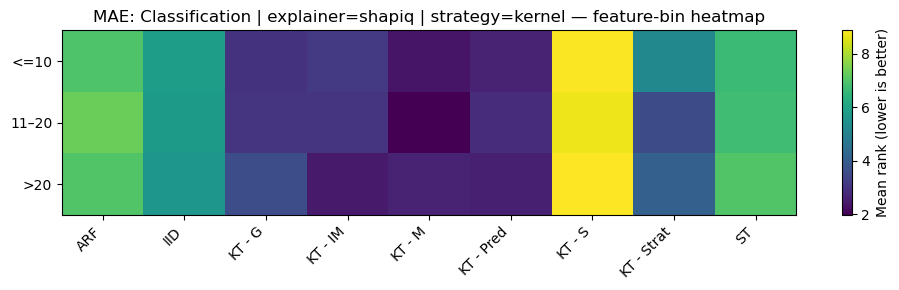

/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_41974/2277959262.py:173: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heat = sub.groupby(["feature_bin", "method"])["rank"].mean().unstack()


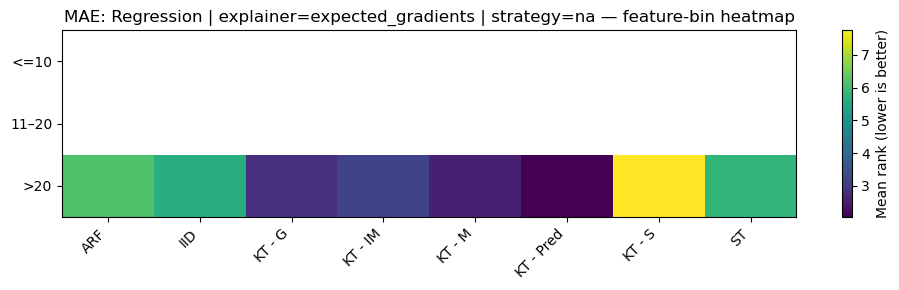

/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_41974/2277959262.py:173: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heat = sub.groupby(["feature_bin", "method"])["rank"].mean().unstack()


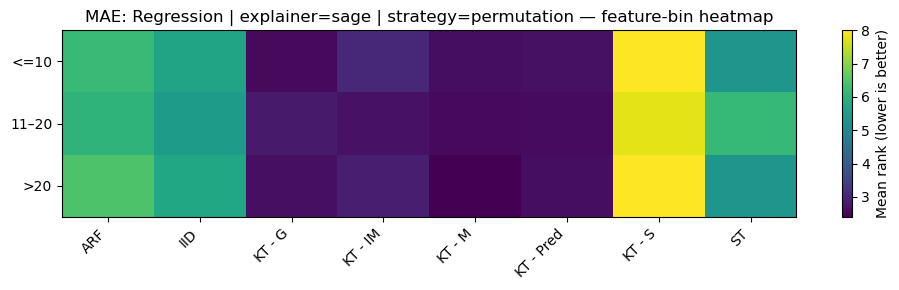

/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_41974/2277959262.py:173: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heat = sub.groupby(["feature_bin", "method"])["rank"].mean().unstack()


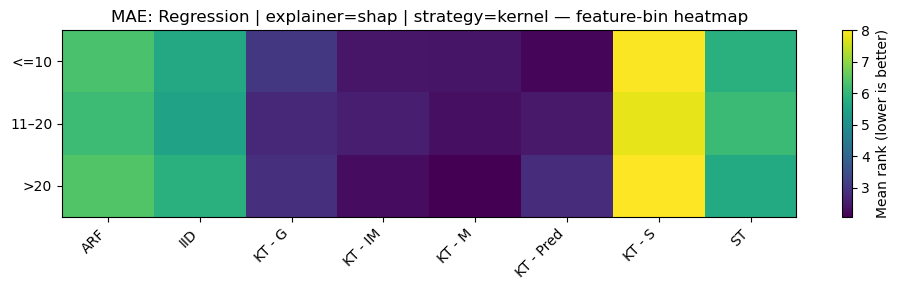

/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_41974/2277959262.py:173: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heat = sub.groupby(["feature_bin", "method"])["rank"].mean().unstack()


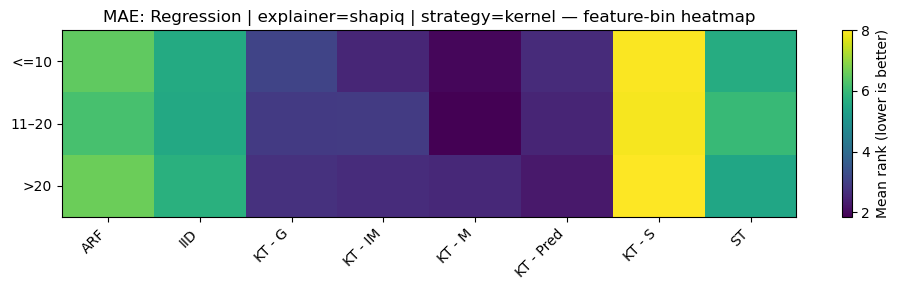

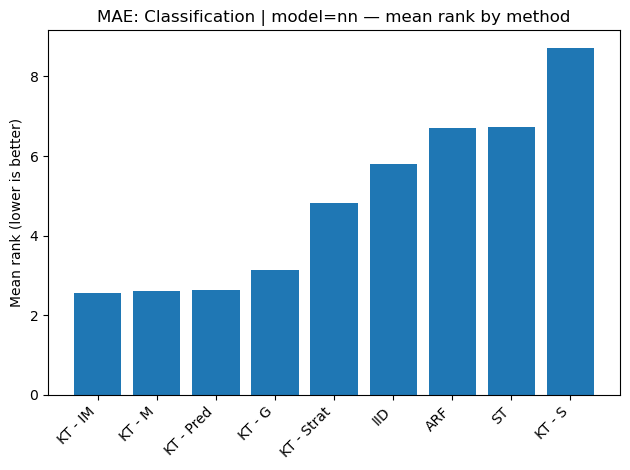

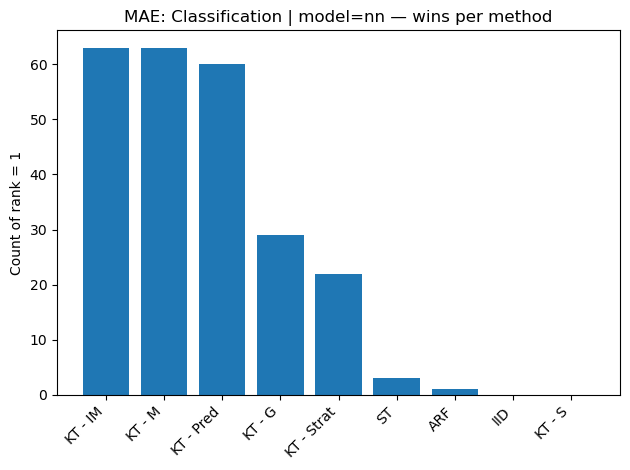

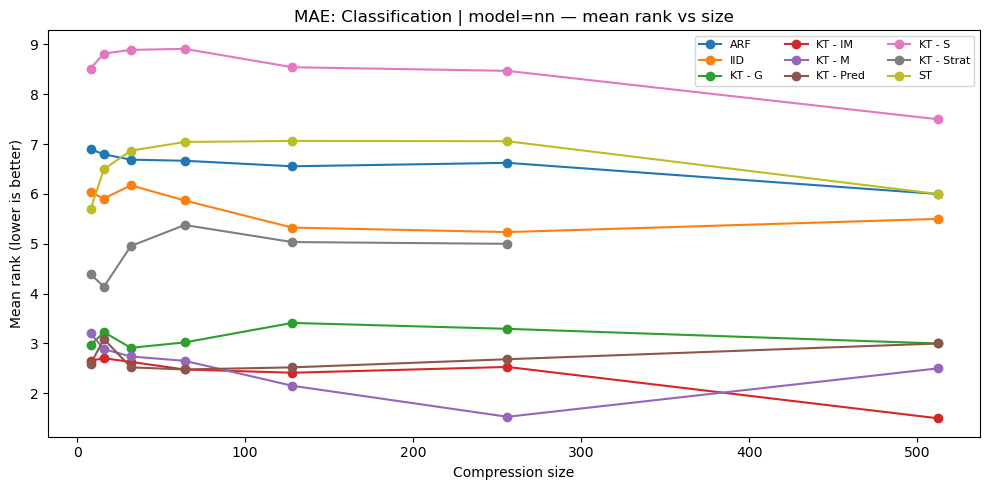

/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_41974/2277959262.py:173: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heat = sub.groupby(["feature_bin", "method"])["rank"].mean().unstack()


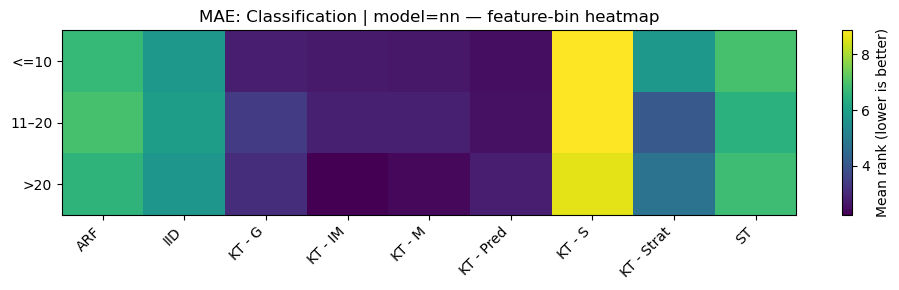

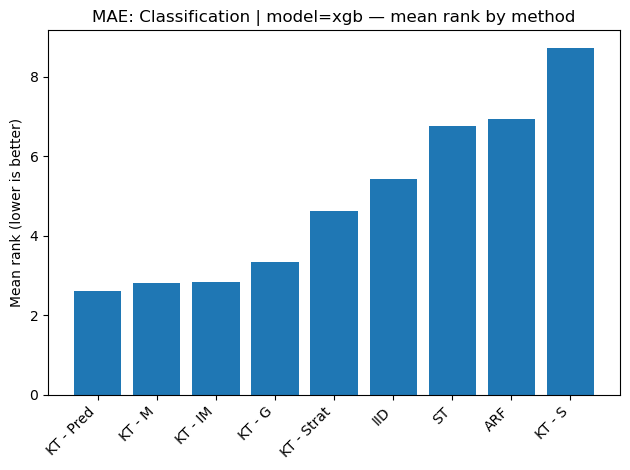

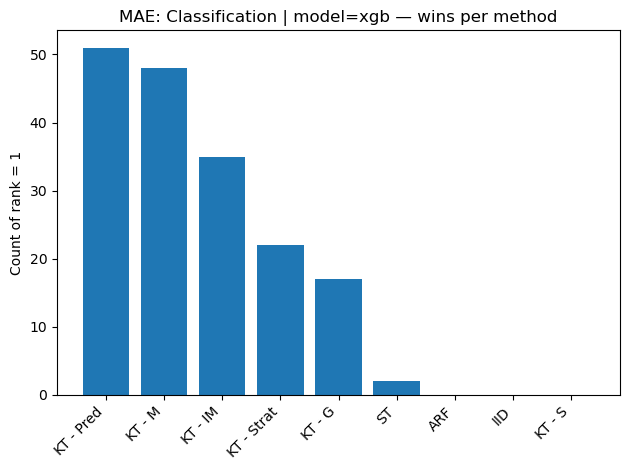

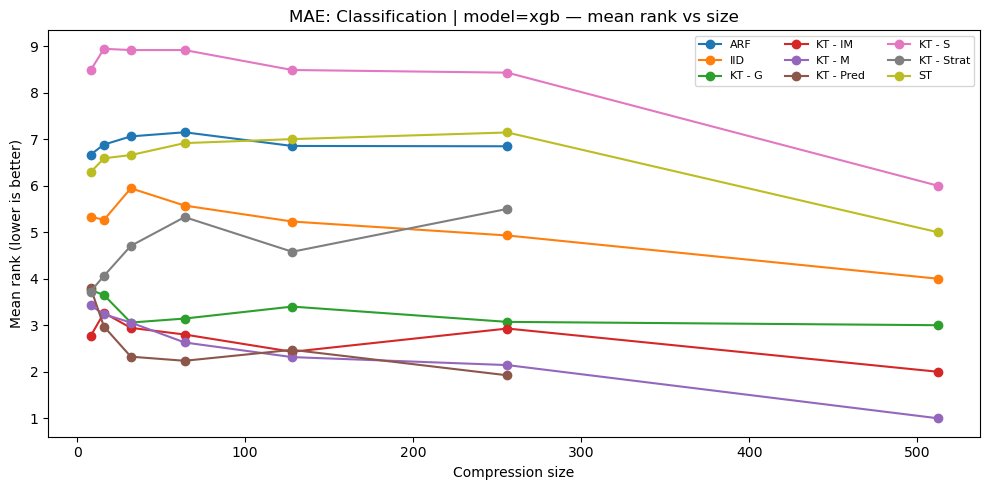

/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_41974/2277959262.py:173: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heat = sub.groupby(["feature_bin", "method"])["rank"].mean().unstack()


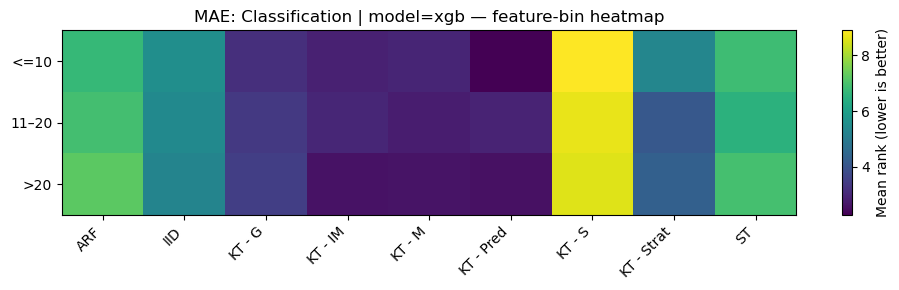

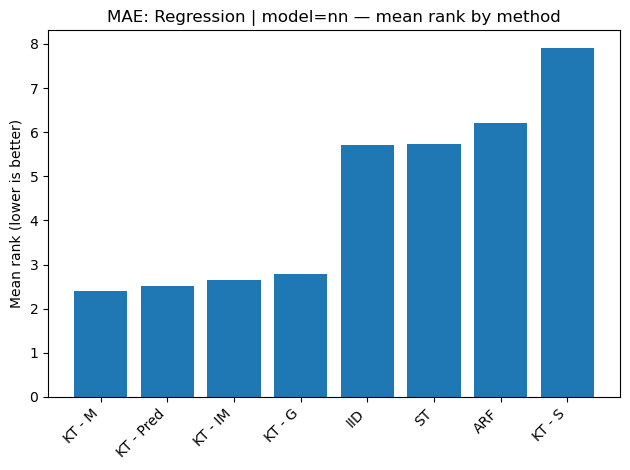

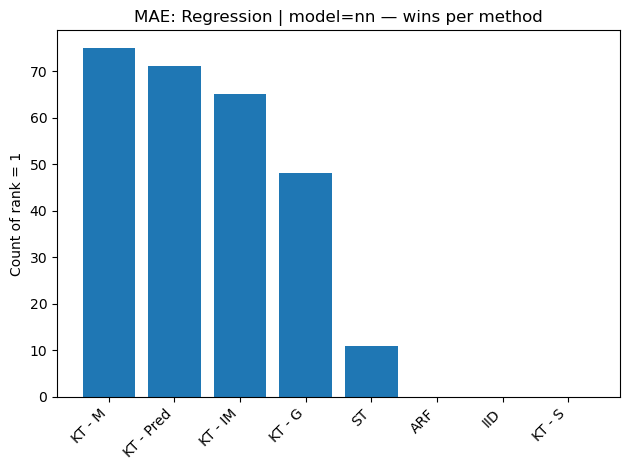

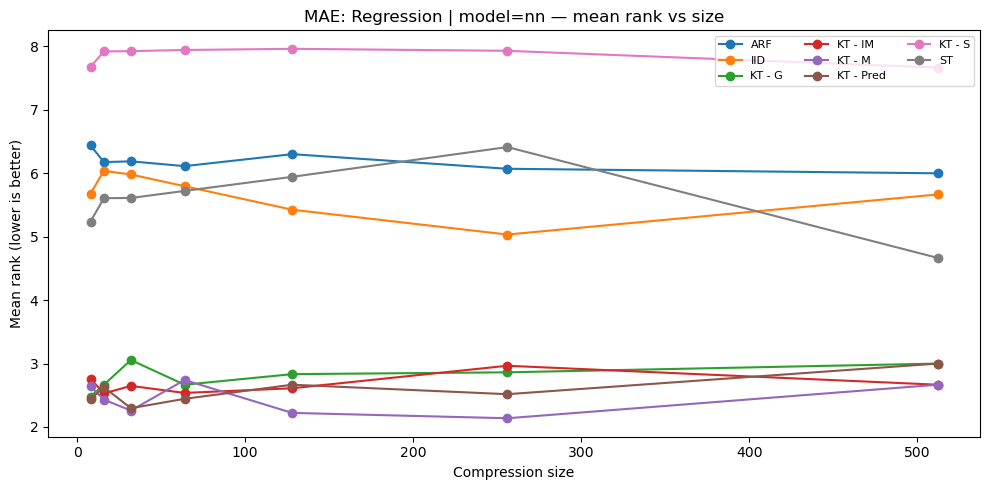

/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_41974/2277959262.py:173: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heat = sub.groupby(["feature_bin", "method"])["rank"].mean().unstack()


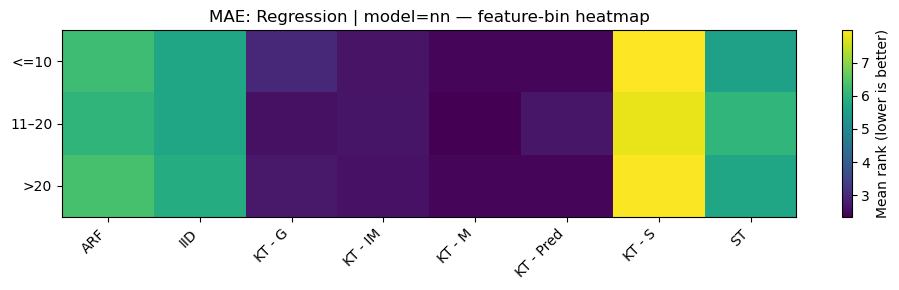

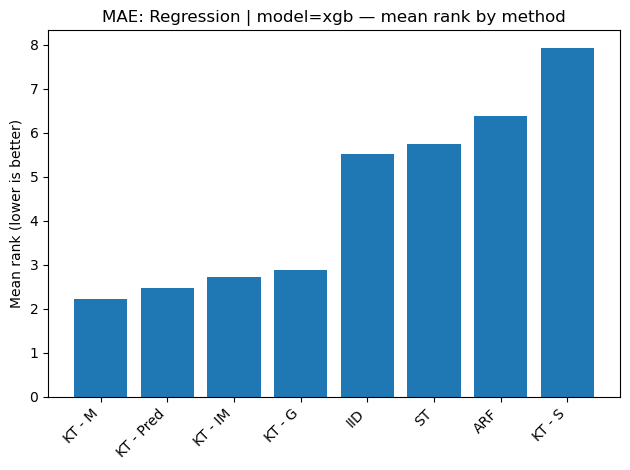

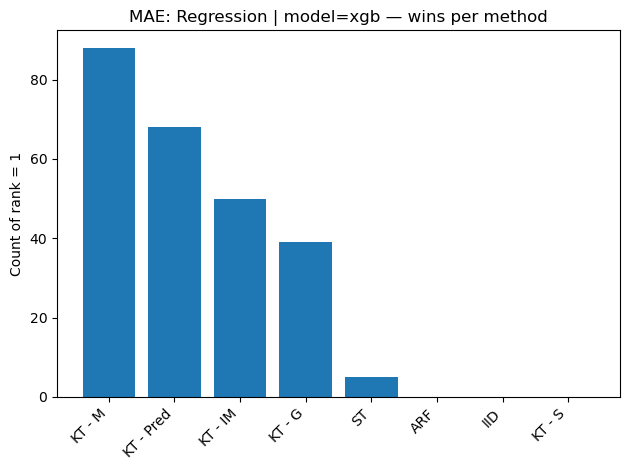

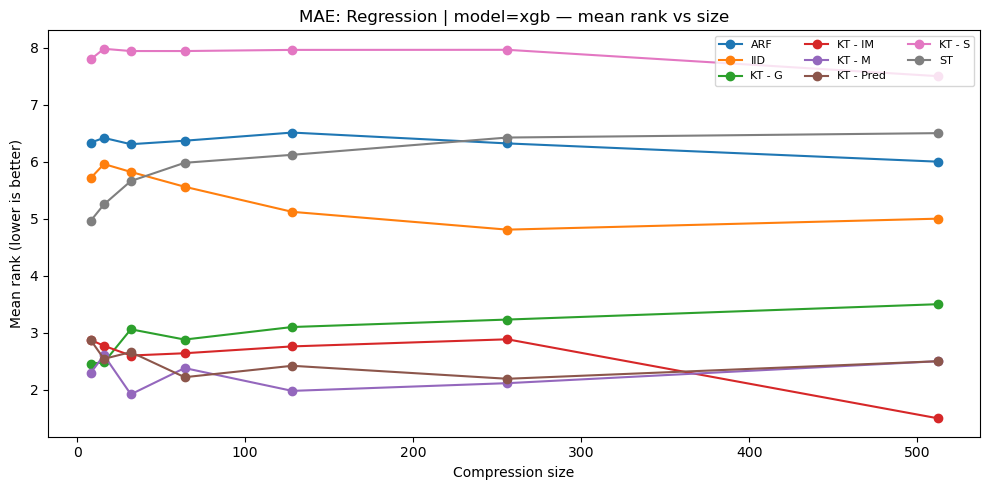

/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_41974/2277959262.py:173: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heat = sub.groupby(["feature_bin", "method"])["rank"].mean().unstack()


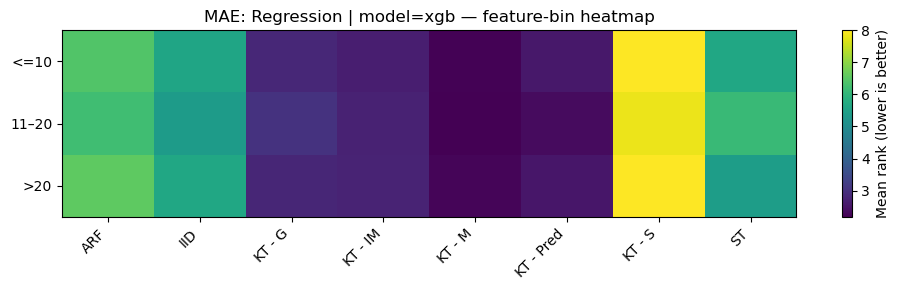


=== BEST METHODS for MAE (lowest mean rank) ===
Global best: KT - M (mean rank=2.48)
Classification : best=KT - Pred (mean rank=2.63)
Regression     : best=KT - M (mean rank=2.32)
Classification  | model=nn : best=KT - IM (mean rank=2.56)
Classification  | model=xgb: best=KT - Pred (mean rank=2.62)
Regression      | model=nn : best=KT - M (mean rank=2.41)
Regression      | model=xgb: best=KT - M (mean rank=2.22)


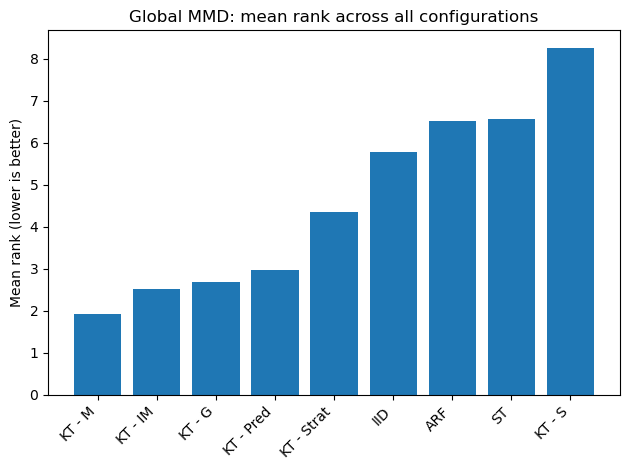

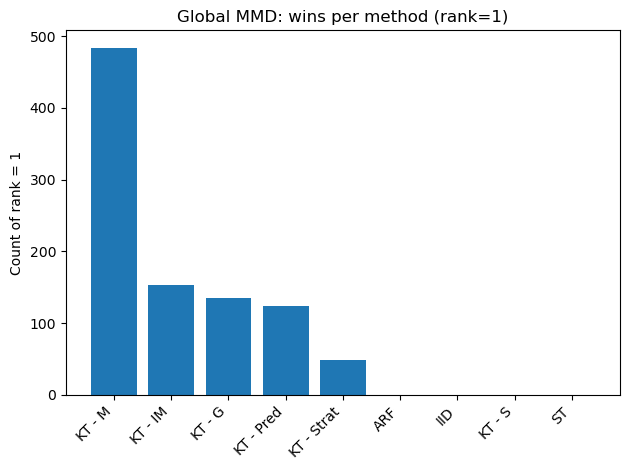

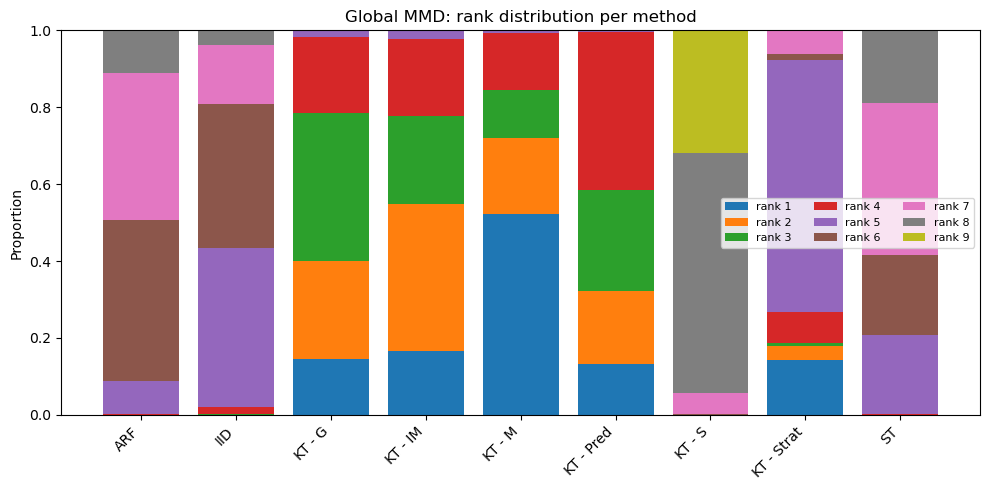

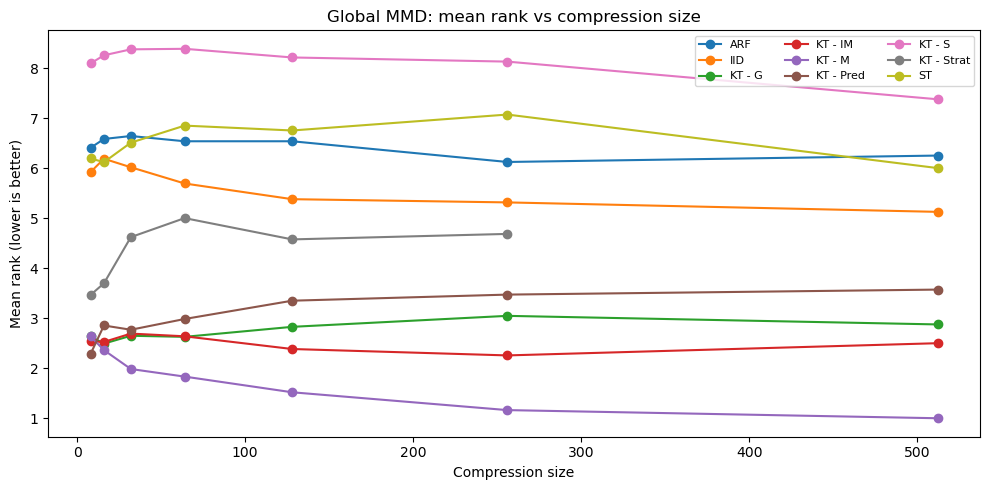

/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_41974/2277959262.py:173: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heat = sub.groupby(["feature_bin", "method"])["rank"].mean().unstack()


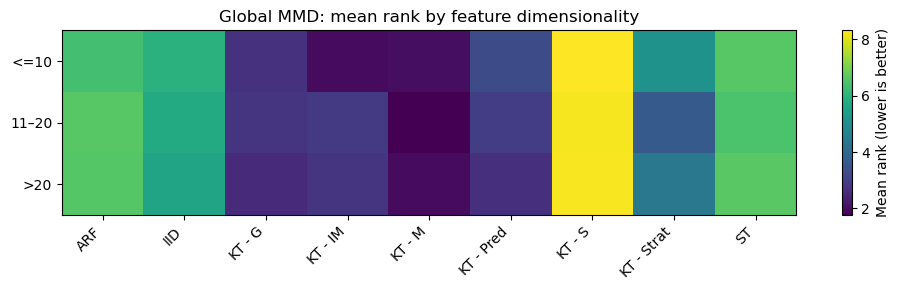

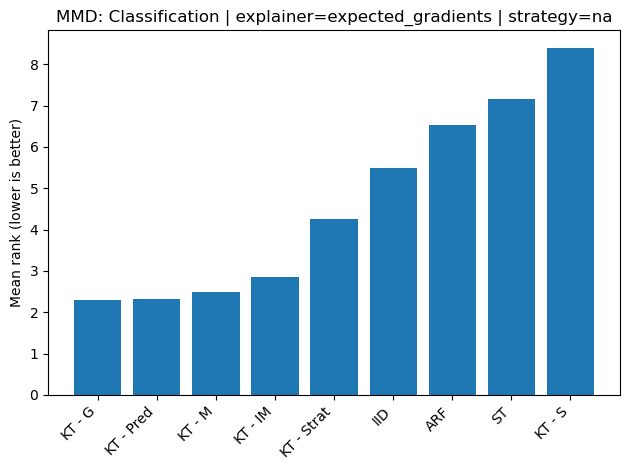

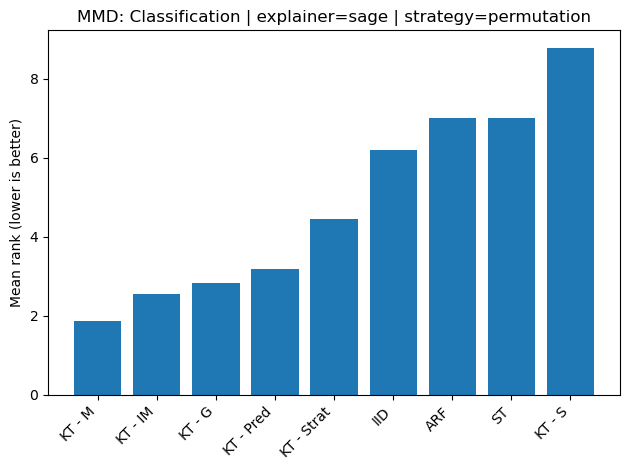

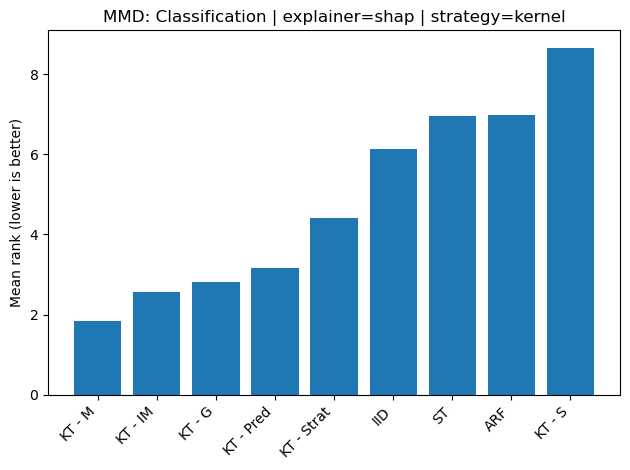

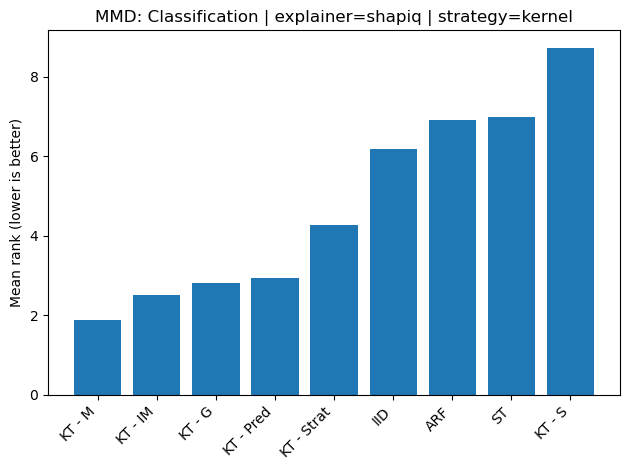

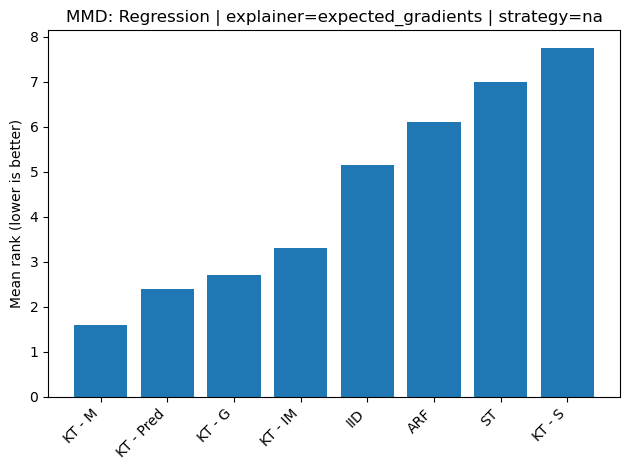

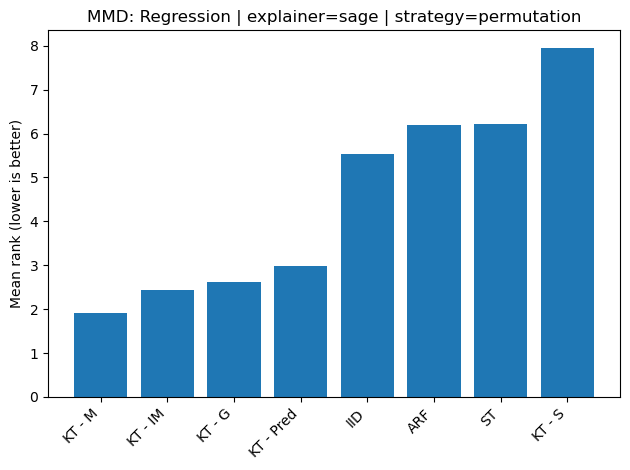

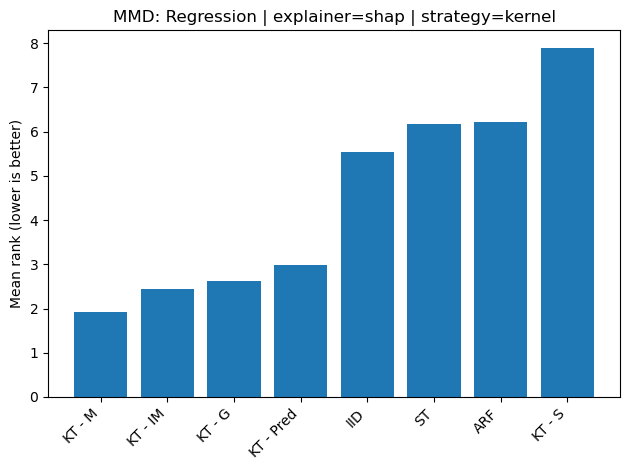

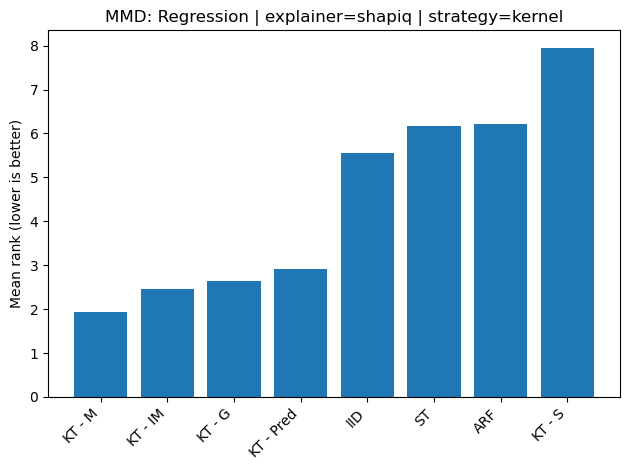

/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_41974/2277959262.py:173: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heat = sub.groupby(["feature_bin", "method"])["rank"].mean().unstack()


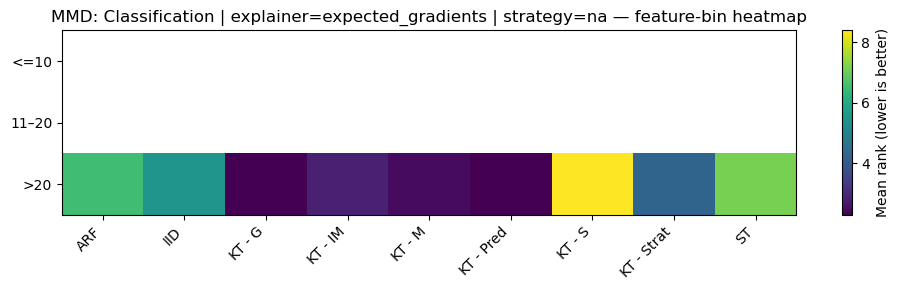

/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_41974/2277959262.py:173: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heat = sub.groupby(["feature_bin", "method"])["rank"].mean().unstack()


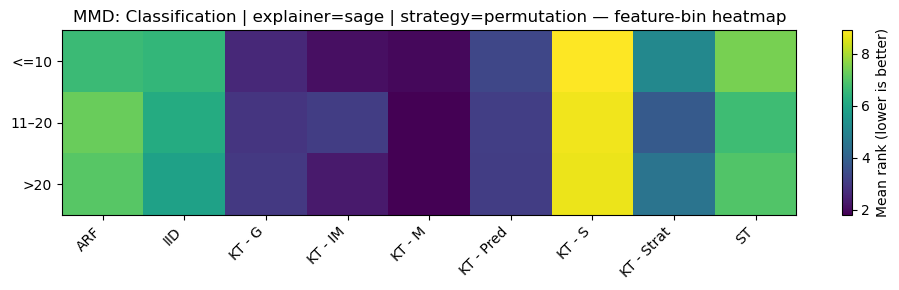

/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_41974/2277959262.py:173: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heat = sub.groupby(["feature_bin", "method"])["rank"].mean().unstack()


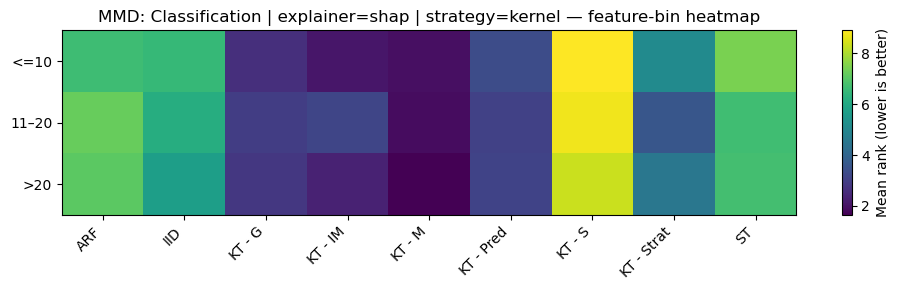

/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_41974/2277959262.py:173: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heat = sub.groupby(["feature_bin", "method"])["rank"].mean().unstack()


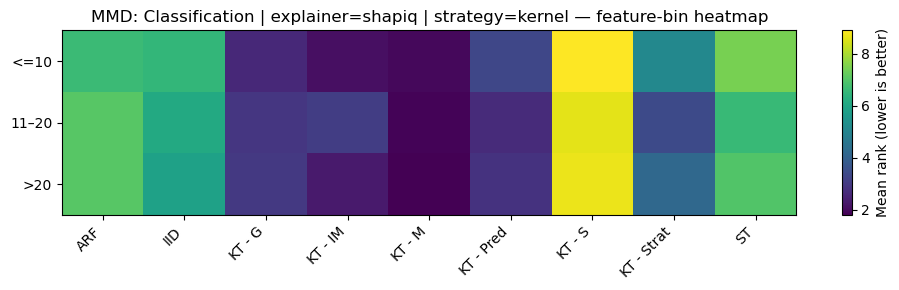

/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_41974/2277959262.py:173: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heat = sub.groupby(["feature_bin", "method"])["rank"].mean().unstack()


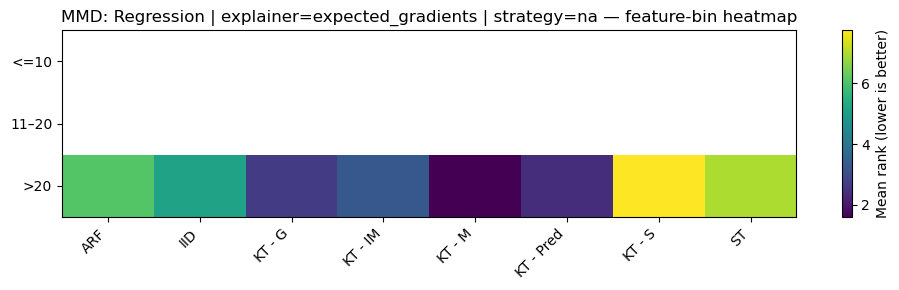

/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_41974/2277959262.py:173: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heat = sub.groupby(["feature_bin", "method"])["rank"].mean().unstack()


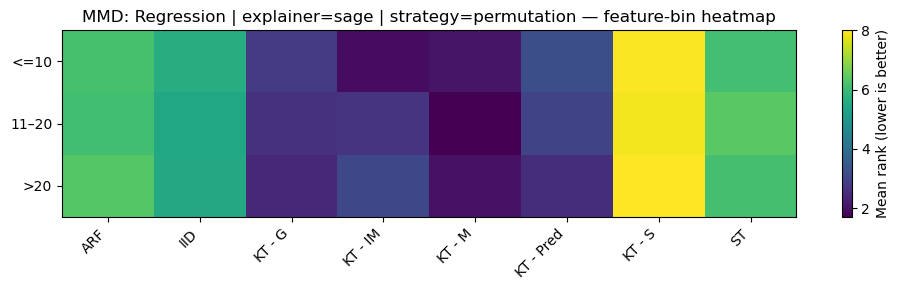

/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_41974/2277959262.py:173: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heat = sub.groupby(["feature_bin", "method"])["rank"].mean().unstack()


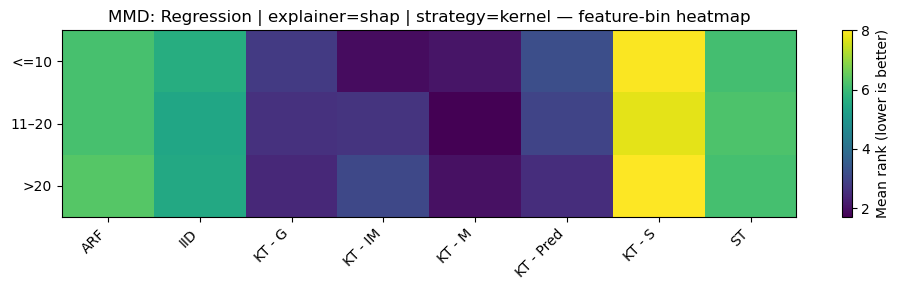

/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_41974/2277959262.py:173: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heat = sub.groupby(["feature_bin", "method"])["rank"].mean().unstack()


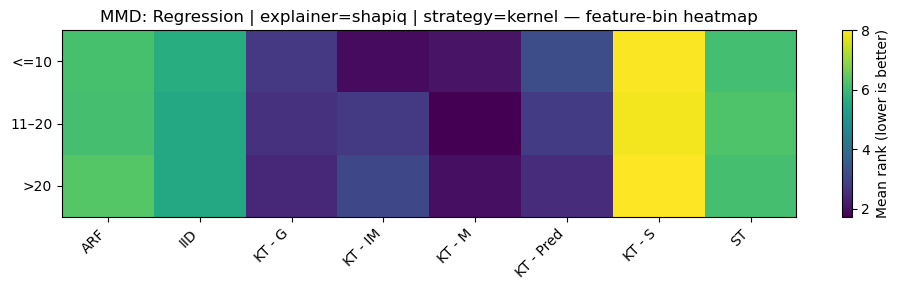

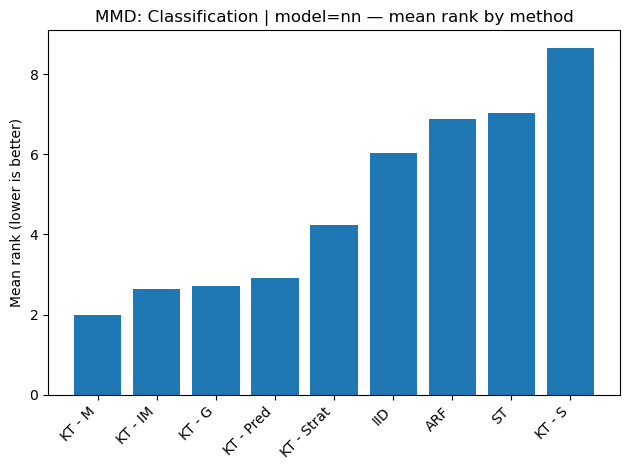

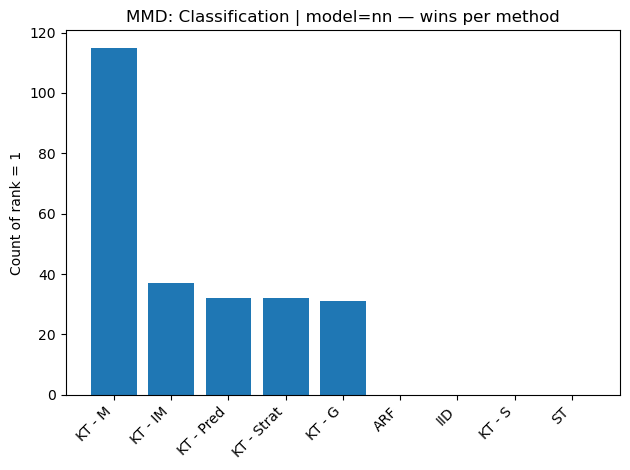

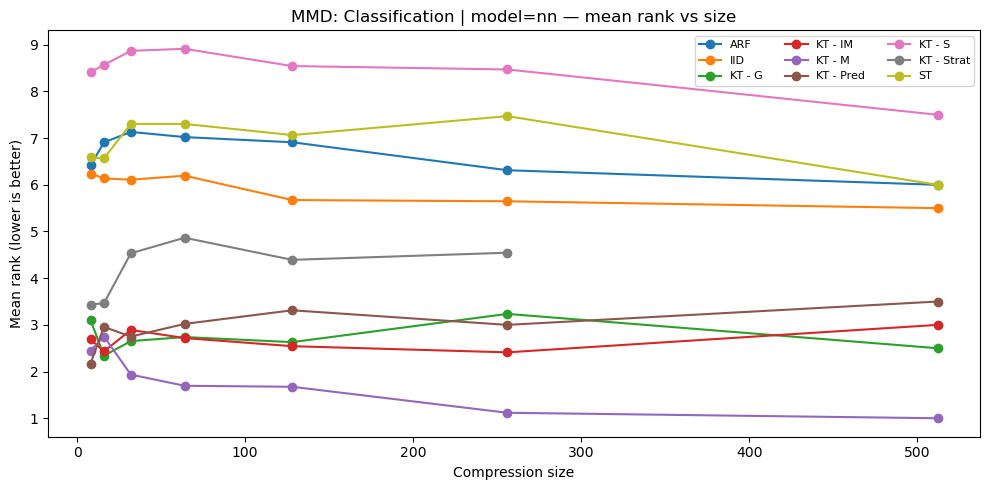

/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_41974/2277959262.py:173: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heat = sub.groupby(["feature_bin", "method"])["rank"].mean().unstack()


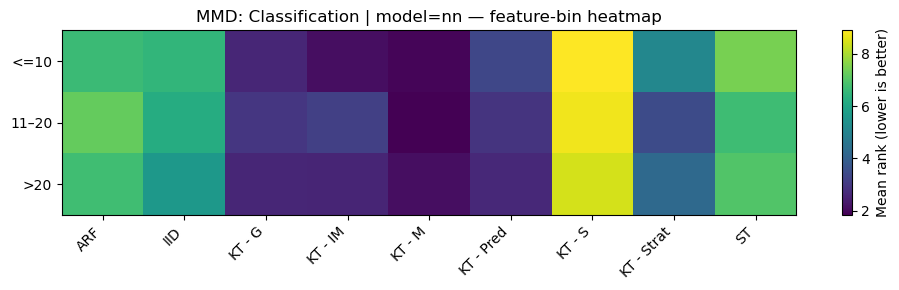

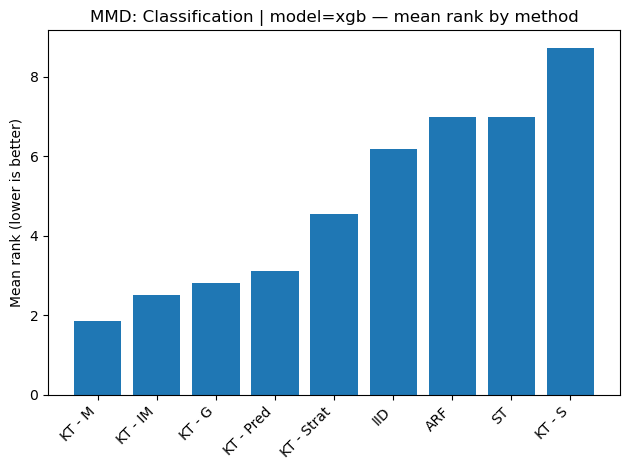

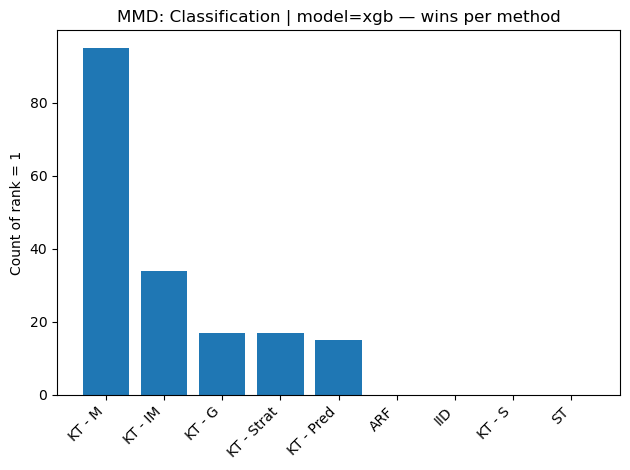

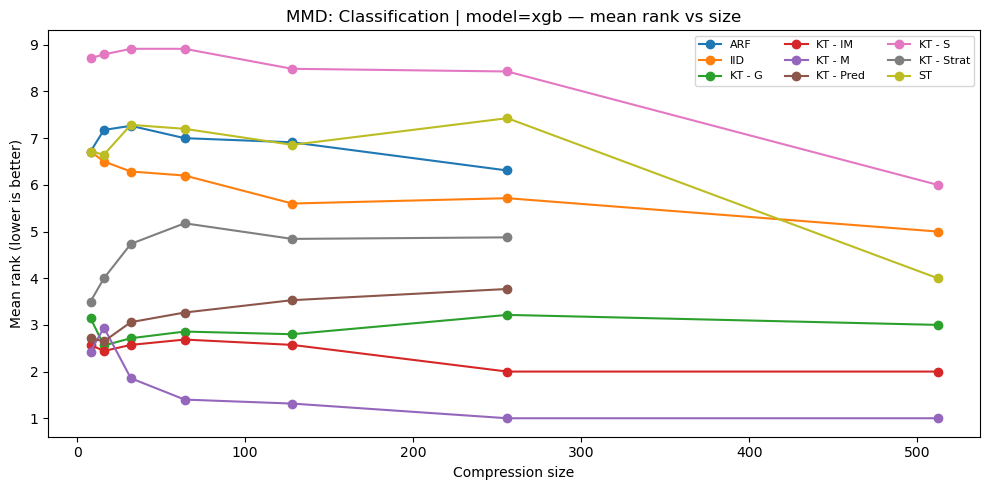

/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_41974/2277959262.py:173: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heat = sub.groupby(["feature_bin", "method"])["rank"].mean().unstack()


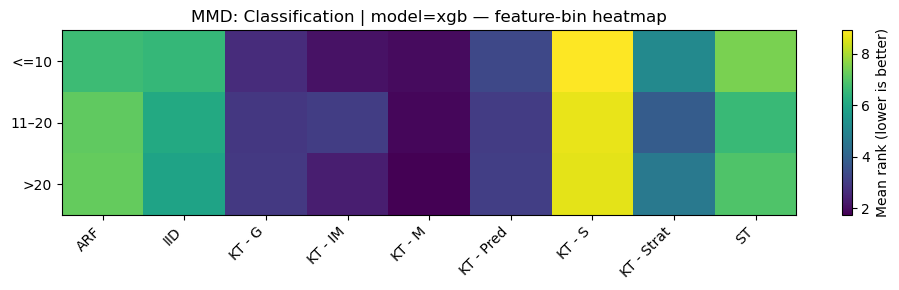

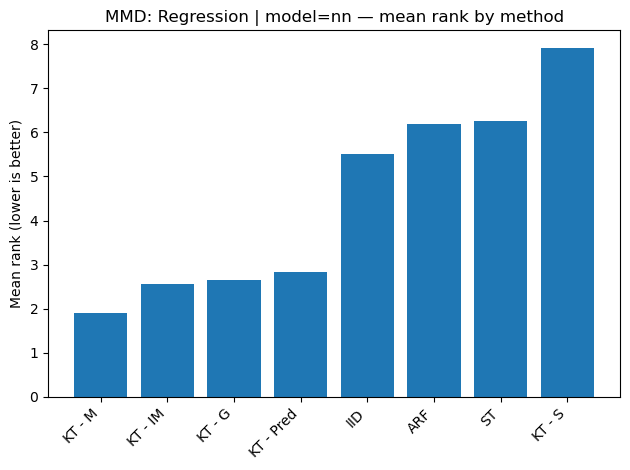

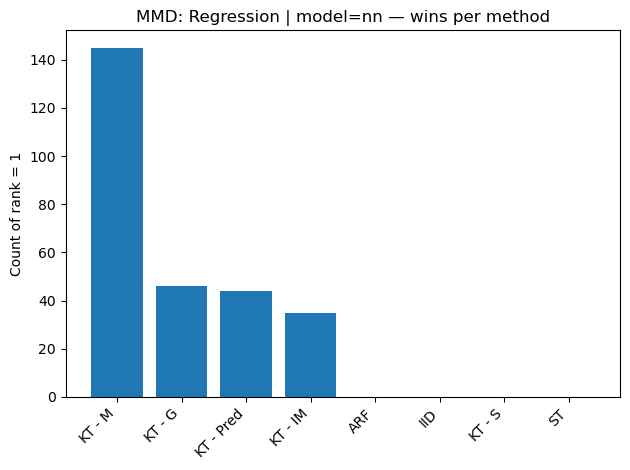

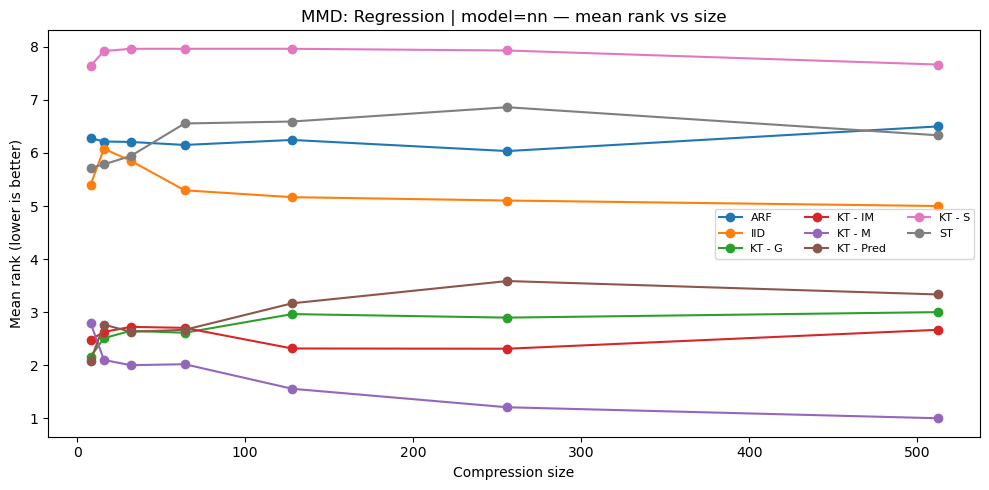

/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_41974/2277959262.py:173: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heat = sub.groupby(["feature_bin", "method"])["rank"].mean().unstack()


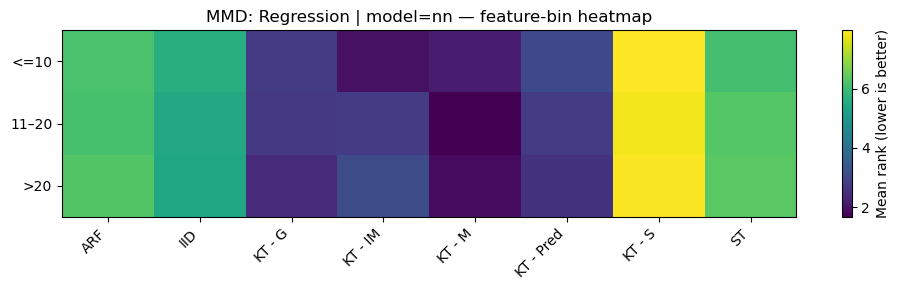

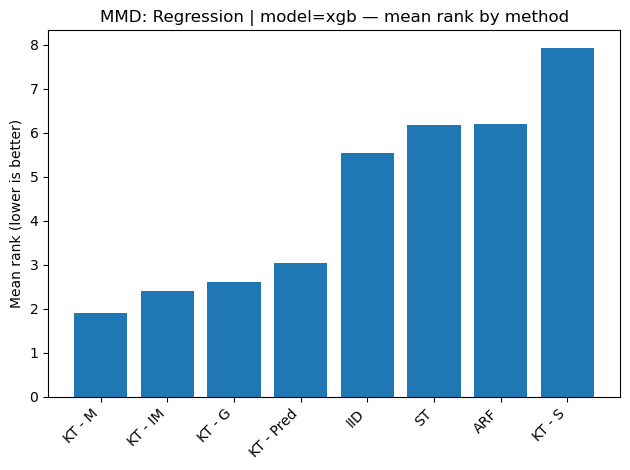

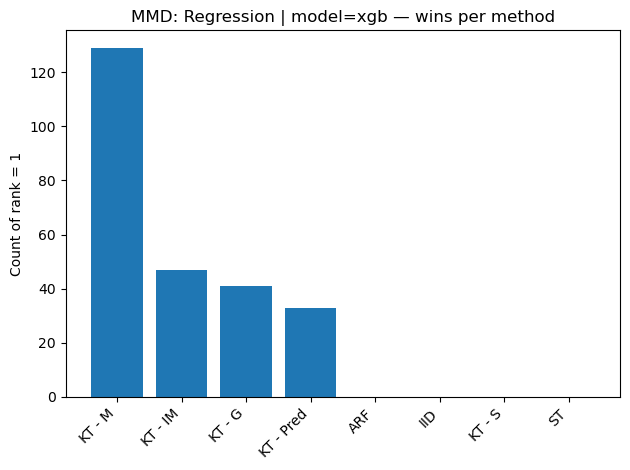

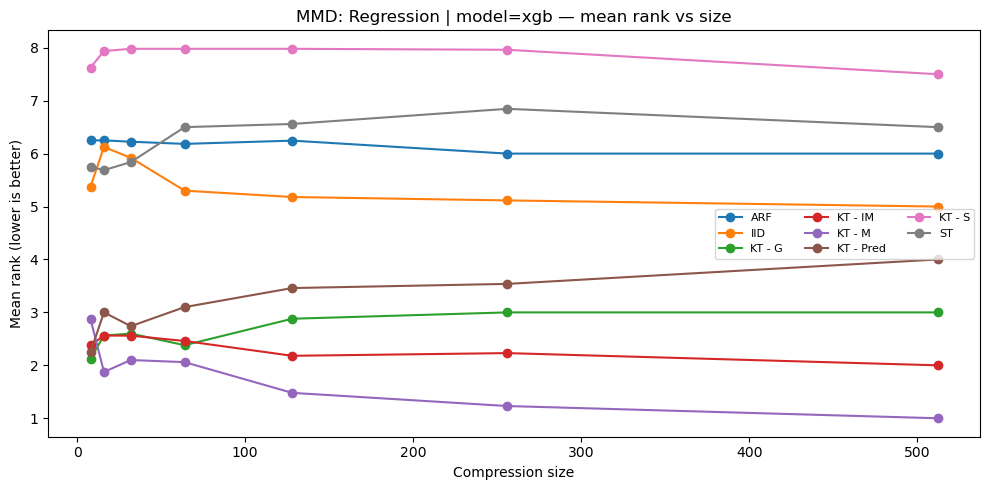

/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_41974/2277959262.py:173: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heat = sub.groupby(["feature_bin", "method"])["rank"].mean().unstack()


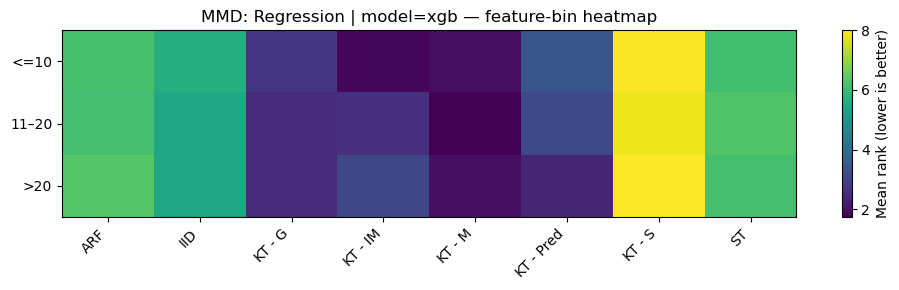


=== BEST METHODS for MMD (lowest mean rank) ===
Global best: KT - M (mean rank=1.92)
Classification : best=KT - M (mean rank=1.93)
Regression     : best=KT - M (mean rank=1.91)
Classification  | model=nn : best=KT - M (mean rank=1.99)
Classification  | model=xgb: best=KT - M (mean rank=1.86)
Regression      | model=nn : best=KT - M (mean rank=1.91)
Regression      | model=xgb: best=KT - M (mean rank=1.90)


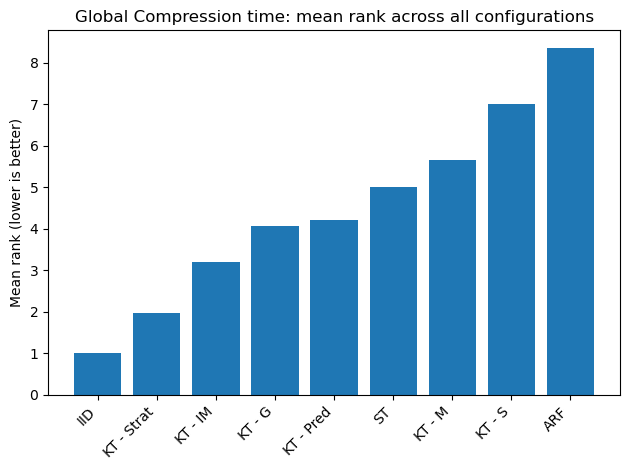

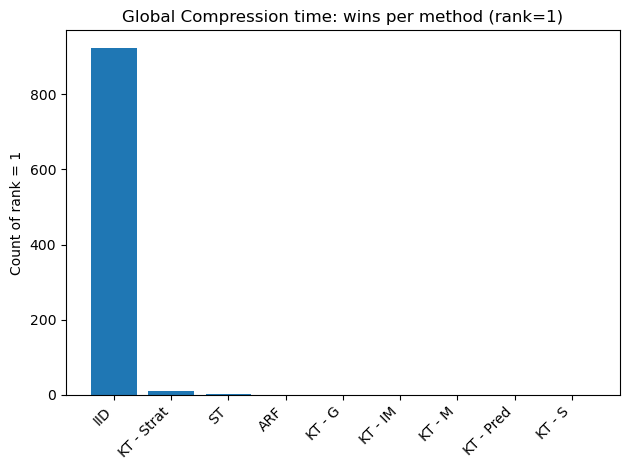

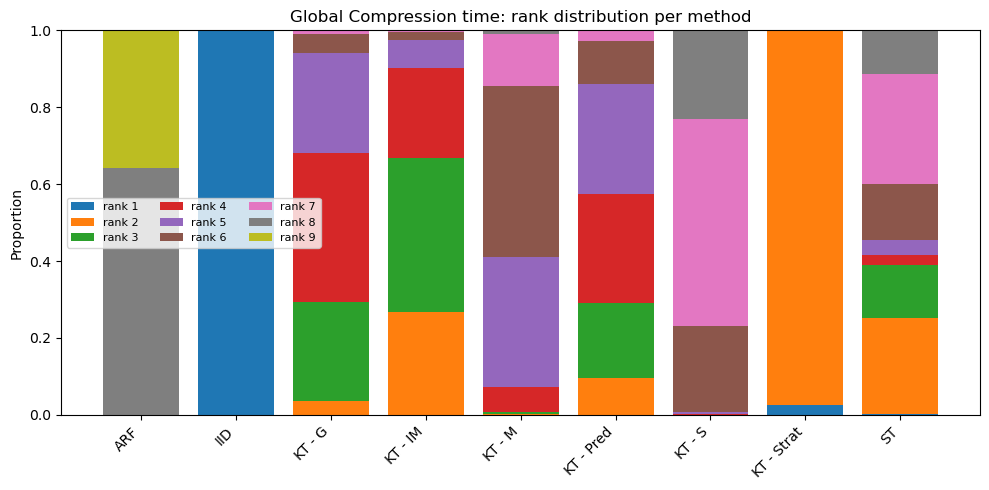

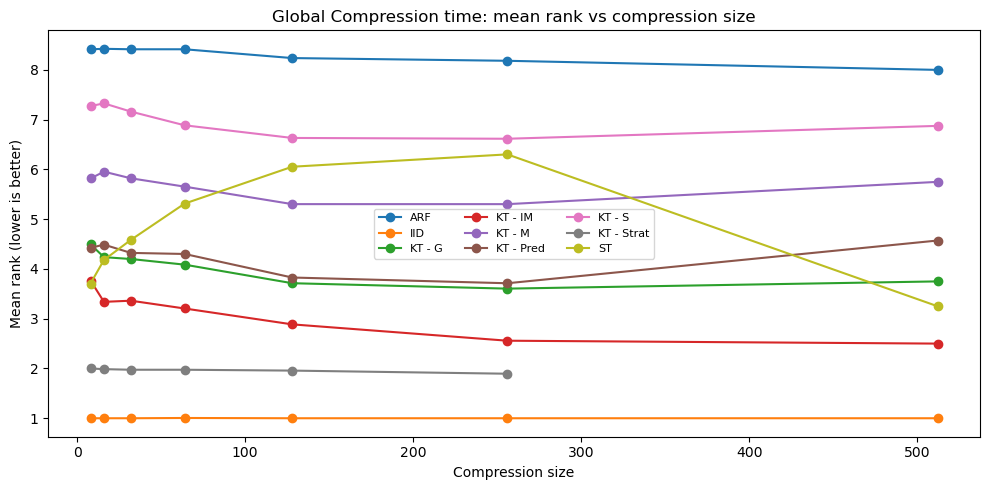

/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_41974/2277959262.py:173: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heat = sub.groupby(["feature_bin", "method"])["rank"].mean().unstack()


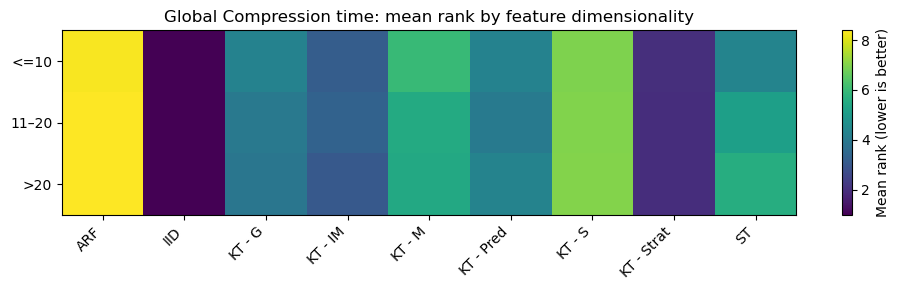

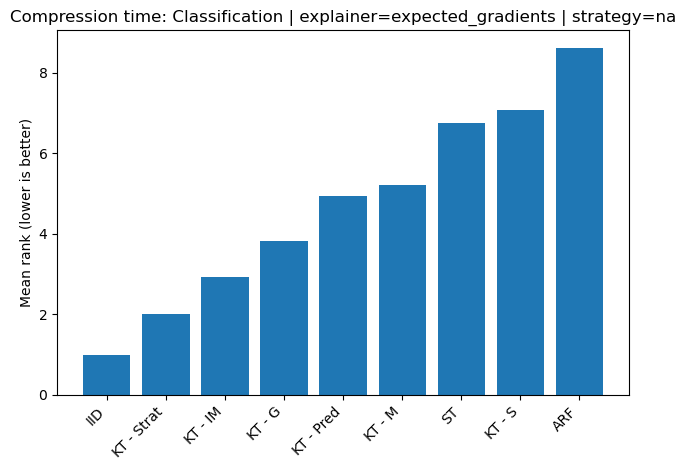

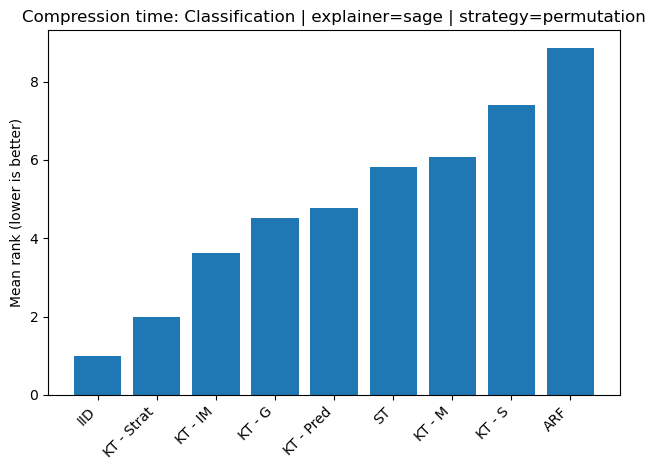

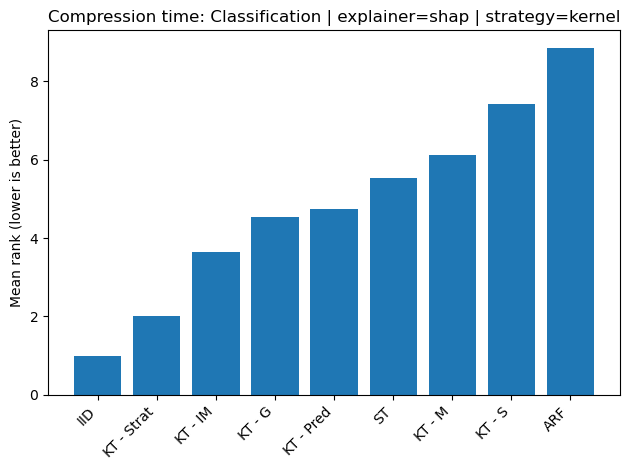

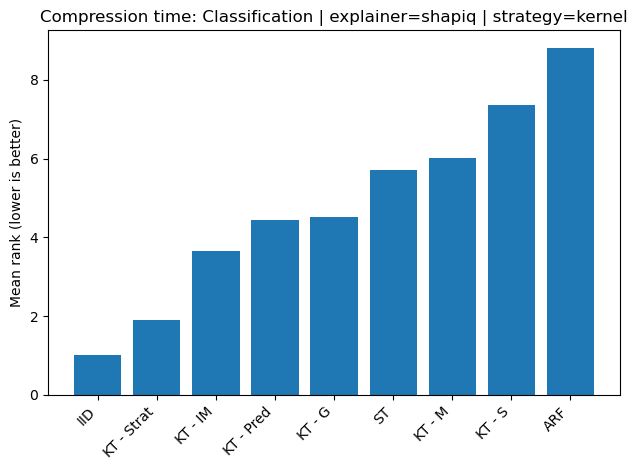

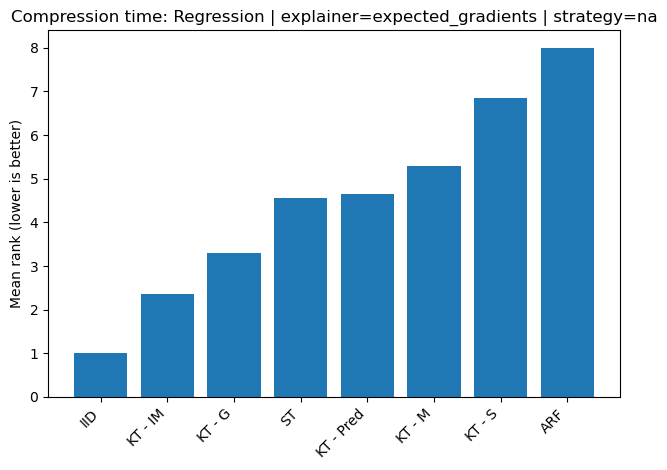

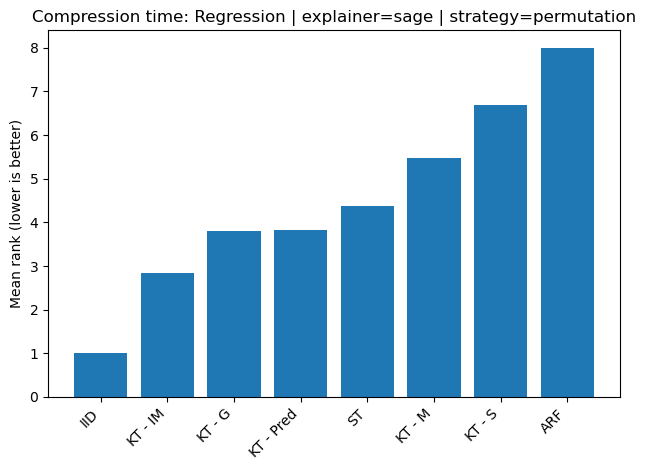

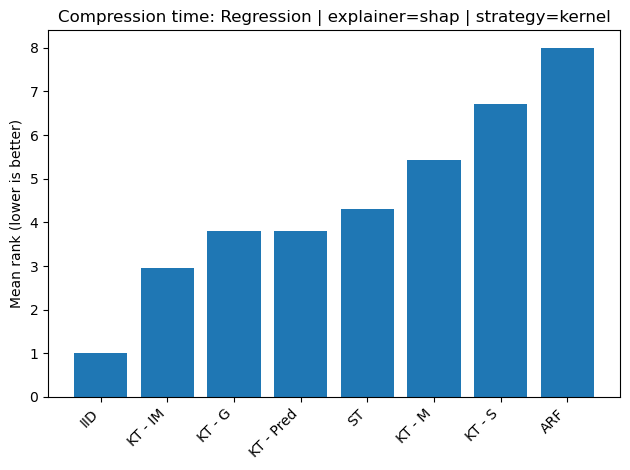

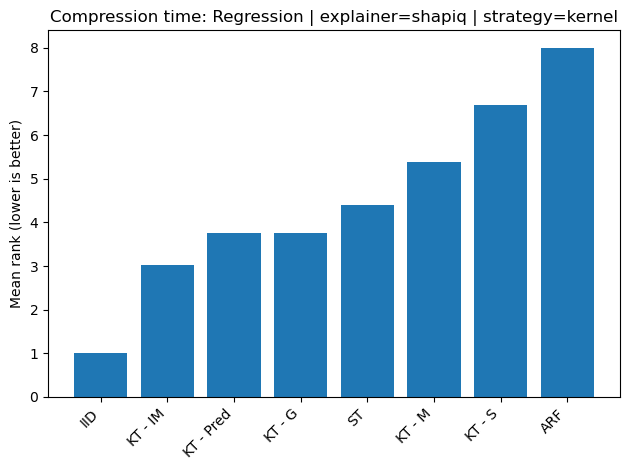

/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_41974/2277959262.py:173: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heat = sub.groupby(["feature_bin", "method"])["rank"].mean().unstack()


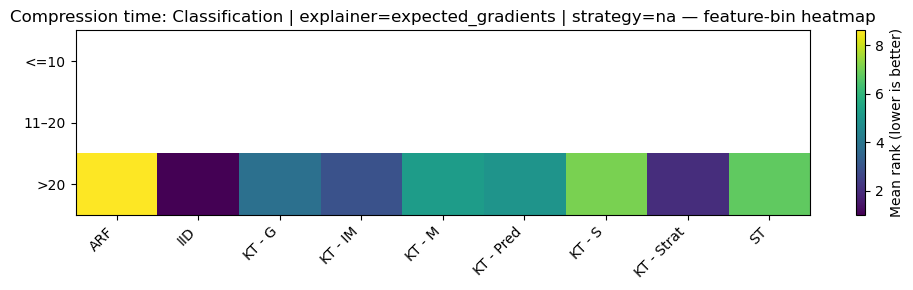

/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_41974/2277959262.py:173: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heat = sub.groupby(["feature_bin", "method"])["rank"].mean().unstack()


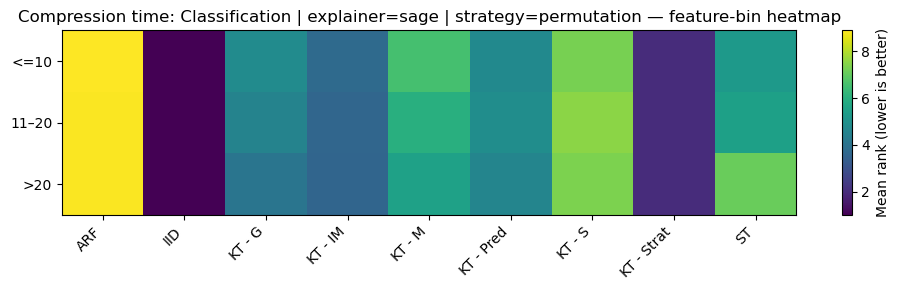

/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_41974/2277959262.py:173: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heat = sub.groupby(["feature_bin", "method"])["rank"].mean().unstack()


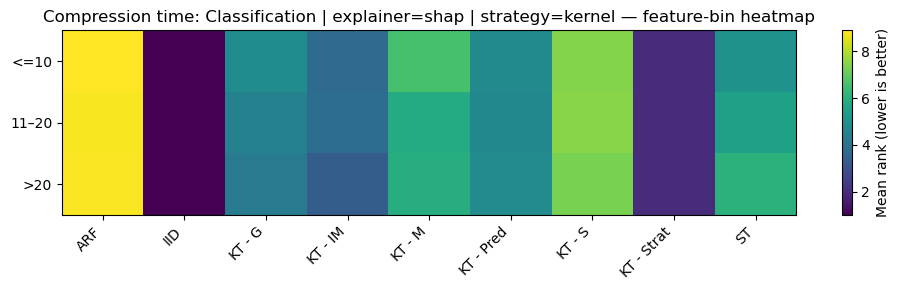

/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_41974/2277959262.py:173: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heat = sub.groupby(["feature_bin", "method"])["rank"].mean().unstack()


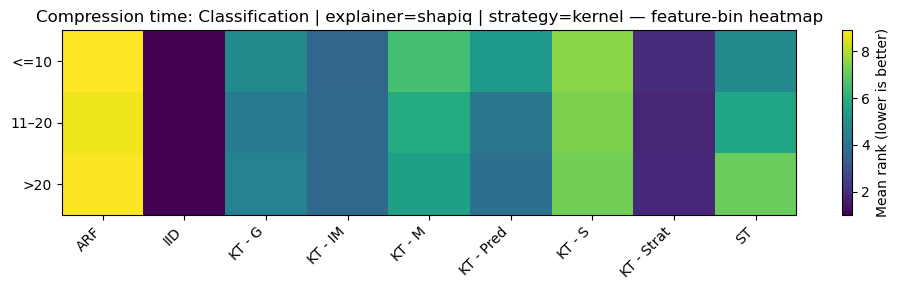

/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_41974/2277959262.py:173: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heat = sub.groupby(["feature_bin", "method"])["rank"].mean().unstack()


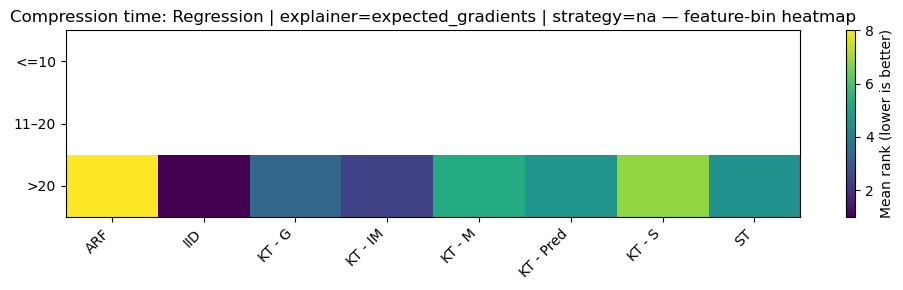

/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_41974/2277959262.py:173: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heat = sub.groupby(["feature_bin", "method"])["rank"].mean().unstack()


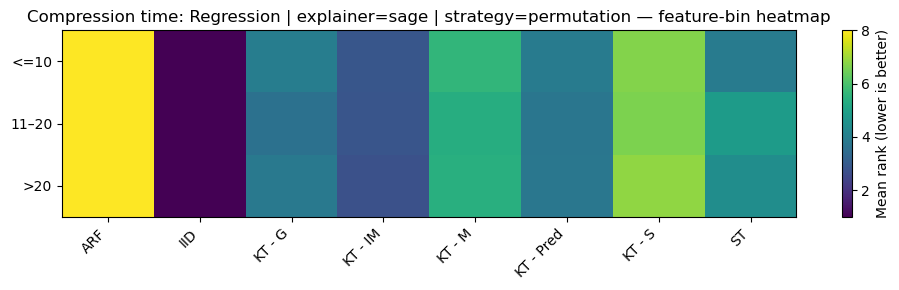

/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_41974/2277959262.py:173: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heat = sub.groupby(["feature_bin", "method"])["rank"].mean().unstack()


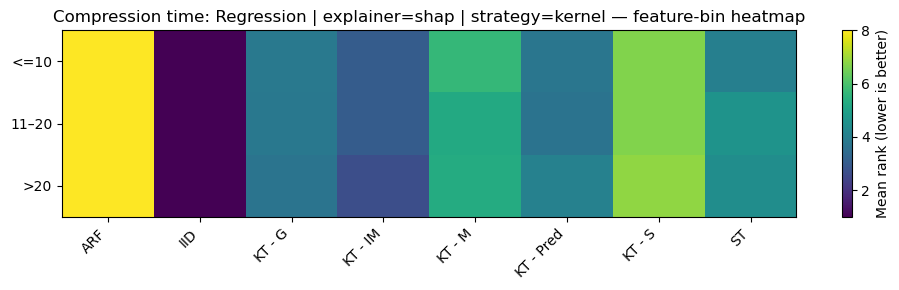

/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_41974/2277959262.py:173: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heat = sub.groupby(["feature_bin", "method"])["rank"].mean().unstack()


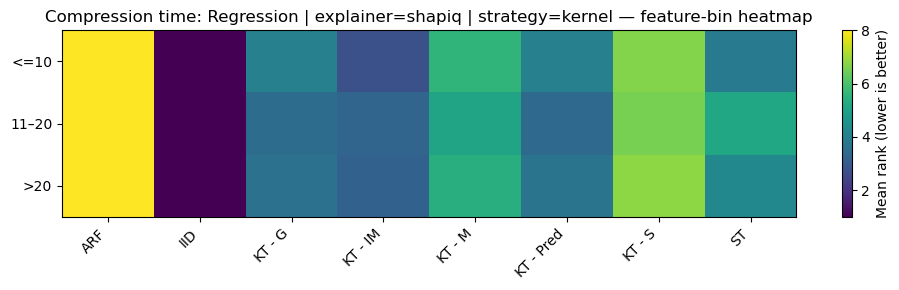

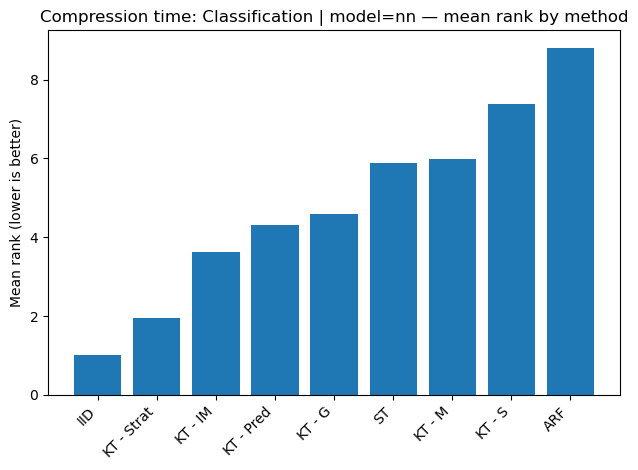

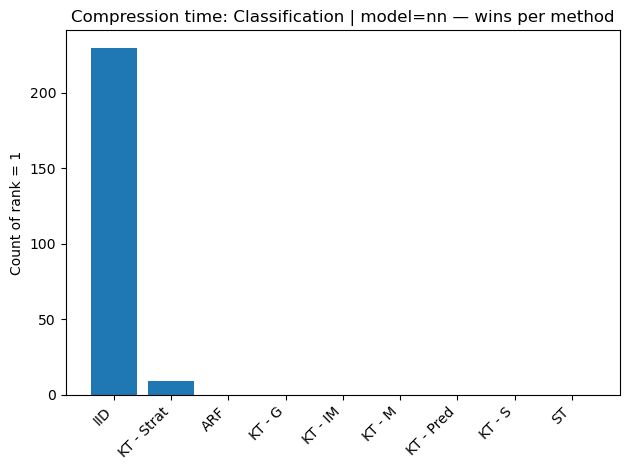

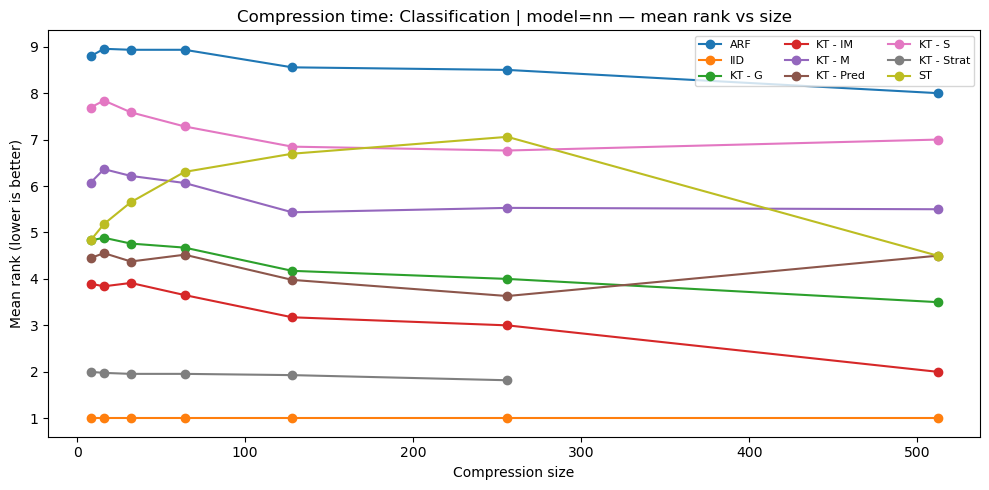

/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_41974/2277959262.py:173: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heat = sub.groupby(["feature_bin", "method"])["rank"].mean().unstack()


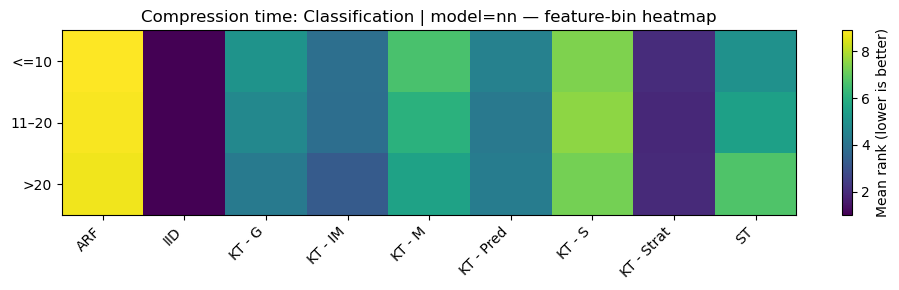

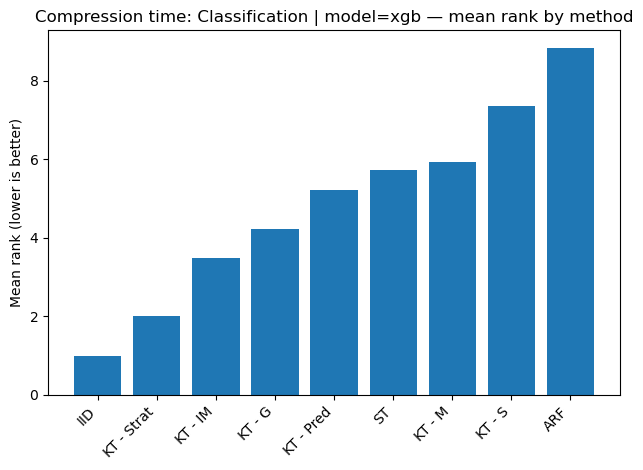

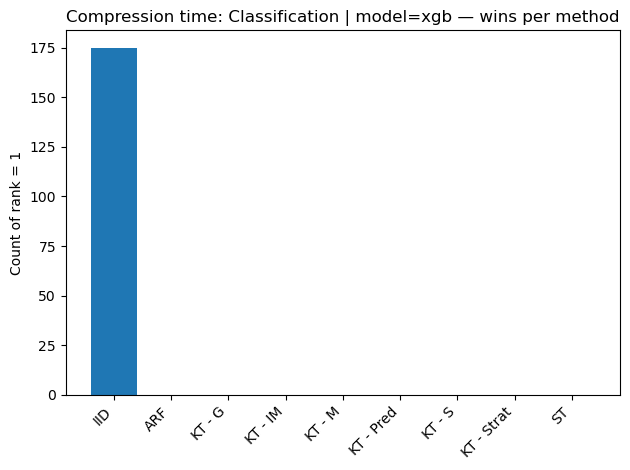

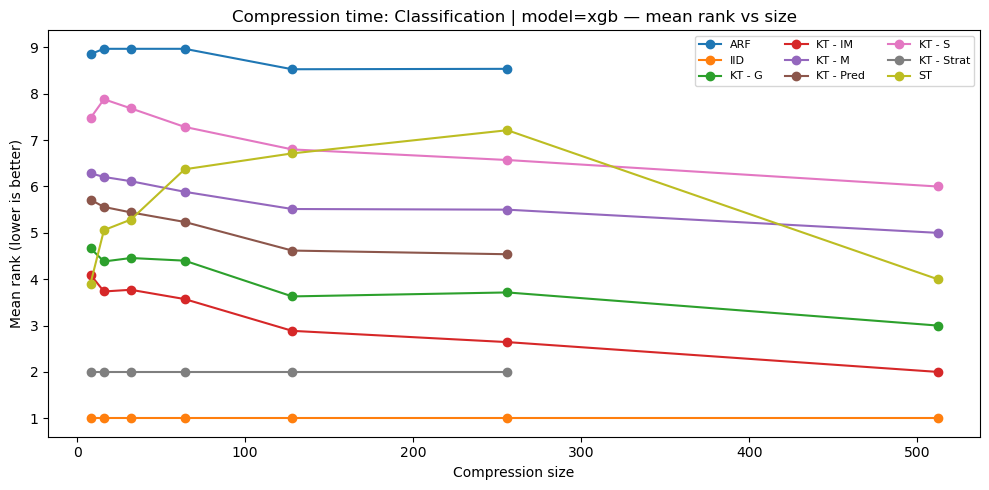

/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_41974/2277959262.py:173: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heat = sub.groupby(["feature_bin", "method"])["rank"].mean().unstack()


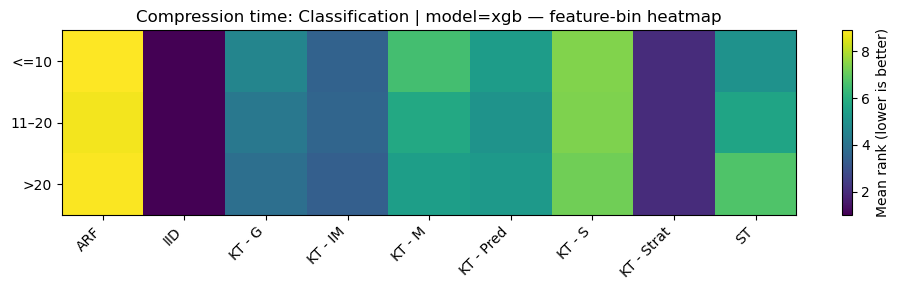

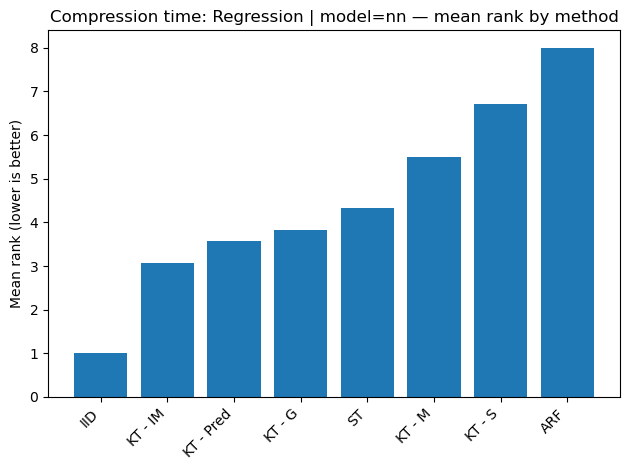

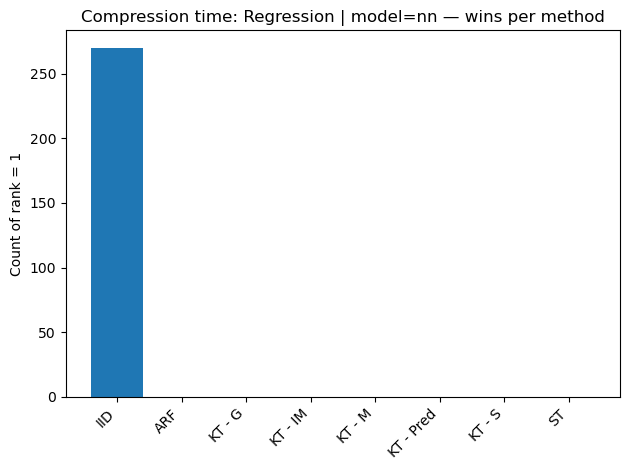

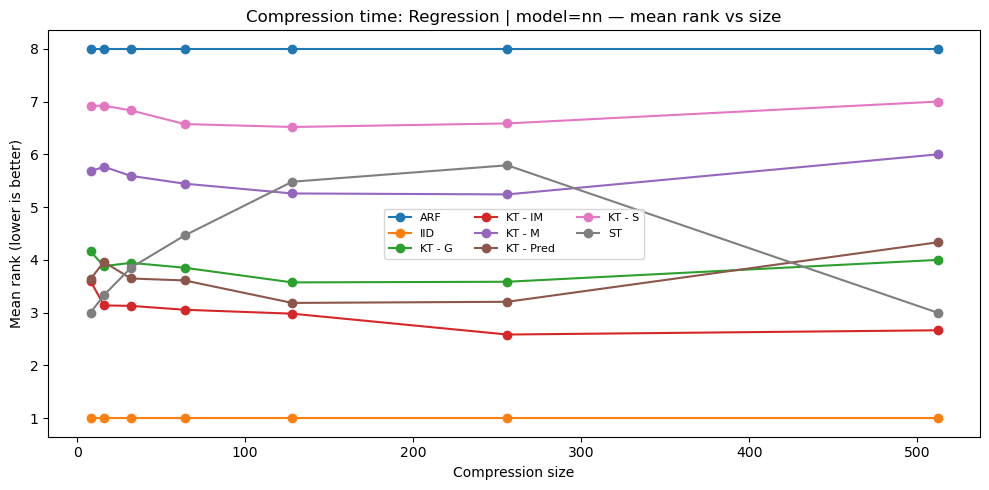

/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_41974/2277959262.py:173: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heat = sub.groupby(["feature_bin", "method"])["rank"].mean().unstack()


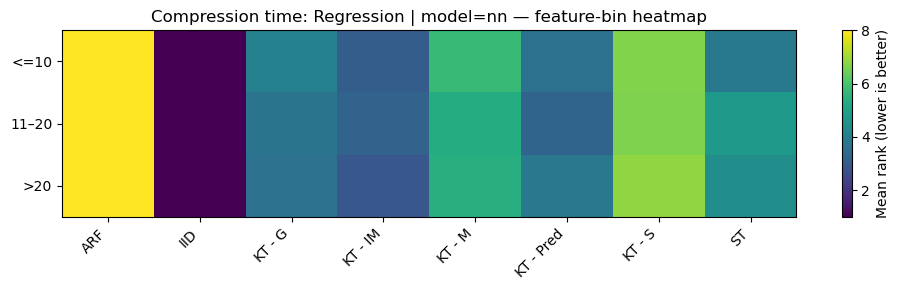

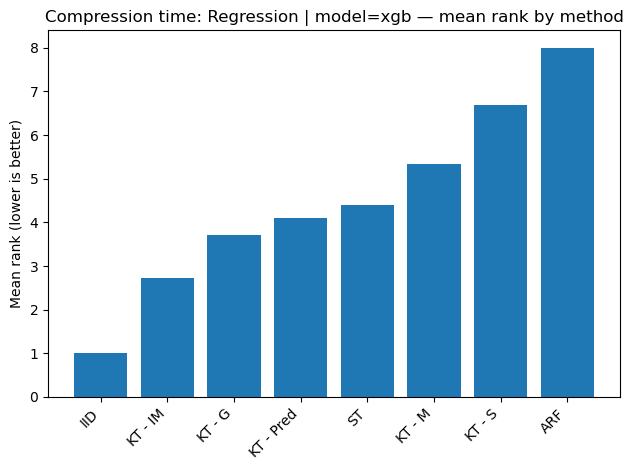

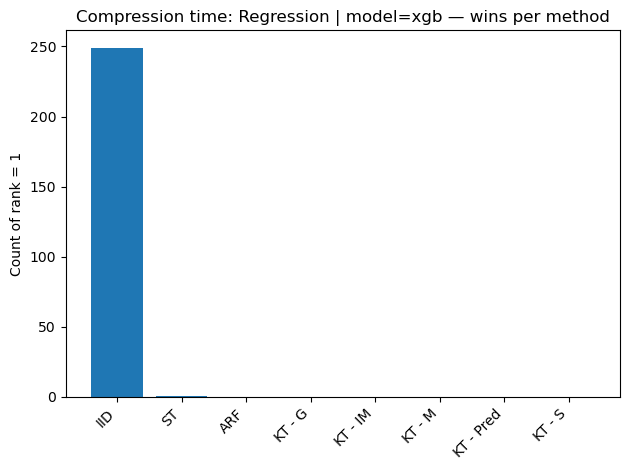

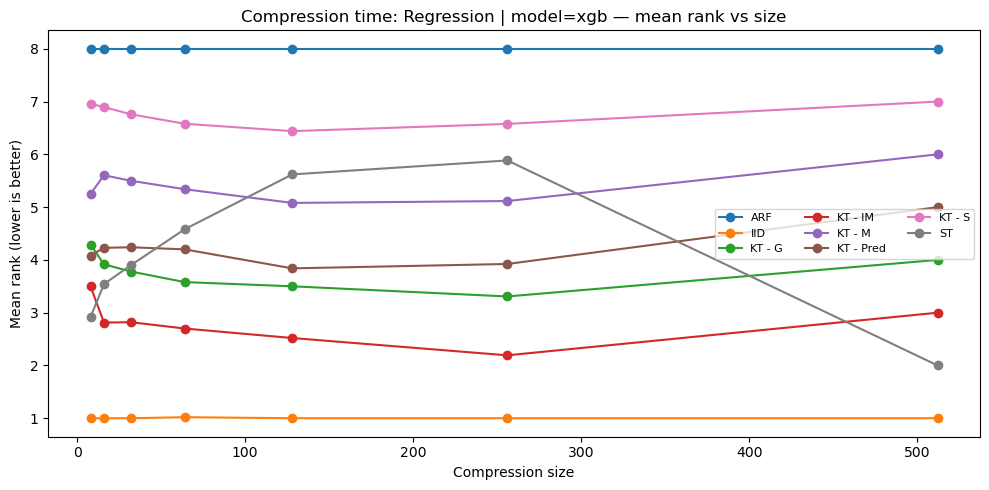

/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_41974/2277959262.py:173: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heat = sub.groupby(["feature_bin", "method"])["rank"].mean().unstack()


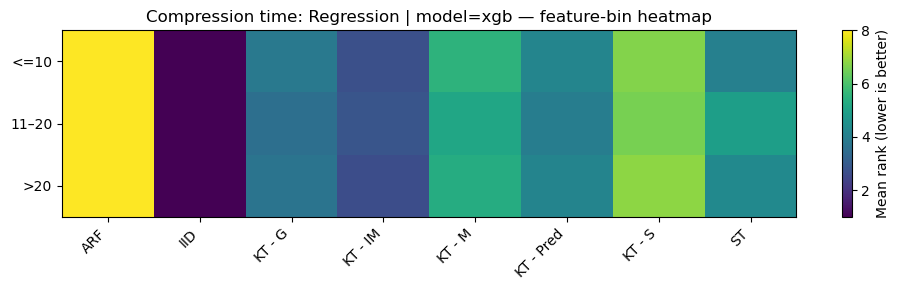


=== BEST METHODS for Compression time (lowest mean rank) ===
Global best: IID (mean rank=1.00)
Classification : best=IID (mean rank=1.00)
Regression     : best=IID (mean rank=1.00)
Classification  | model=nn : best=IID (mean rank=1.00)
Classification  | model=xgb: best=IID (mean rank=1.00)
Regression      | model=nn : best=IID (mean rank=1.00)
Regression      | model=xgb: best=IID (mean rank=1.00)


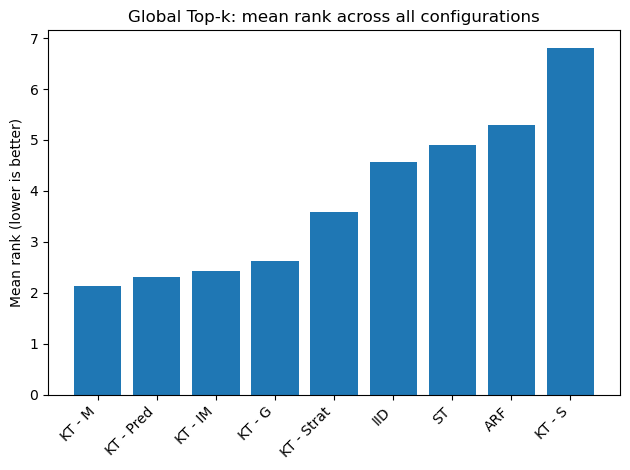

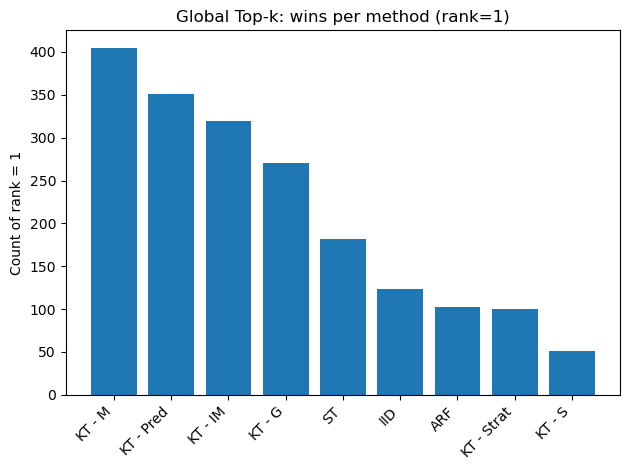

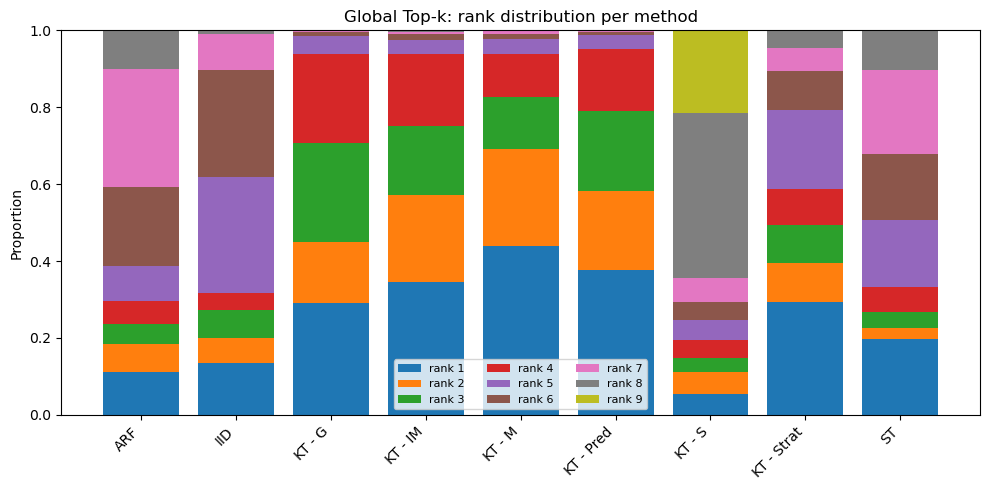

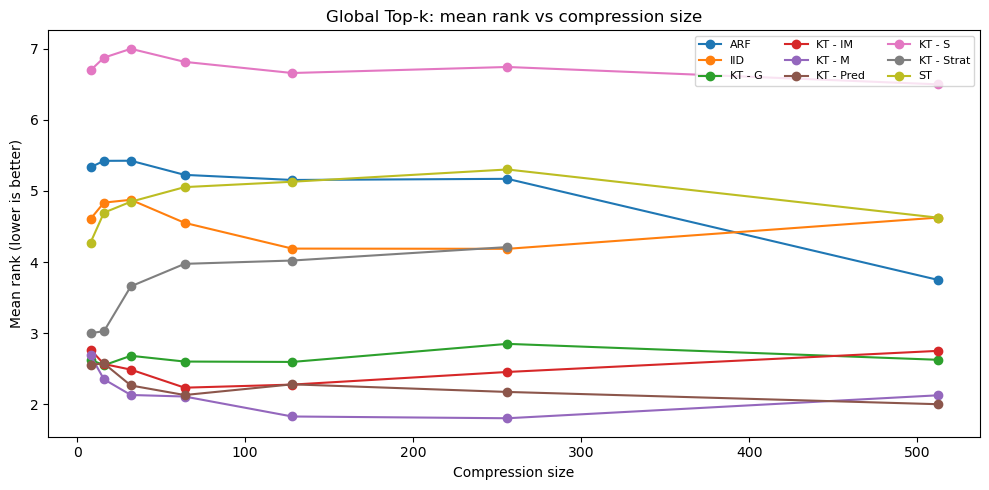

/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_41974/2277959262.py:173: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heat = sub.groupby(["feature_bin", "method"])["rank"].mean().unstack()


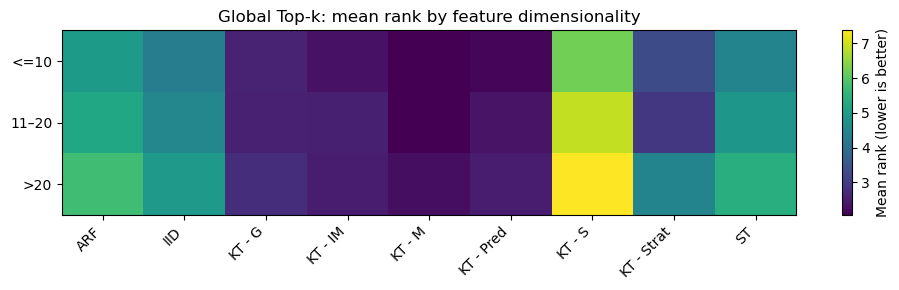

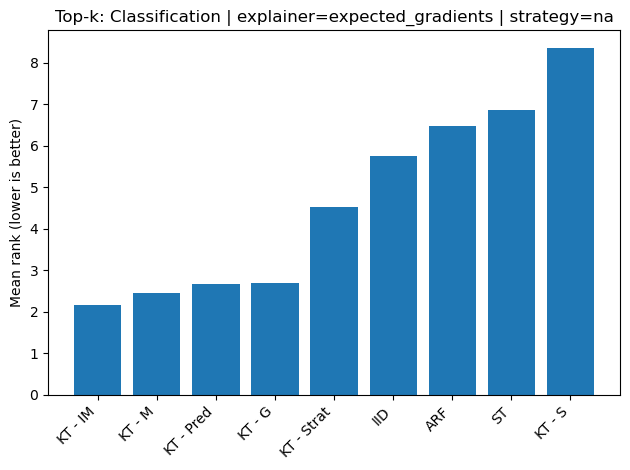

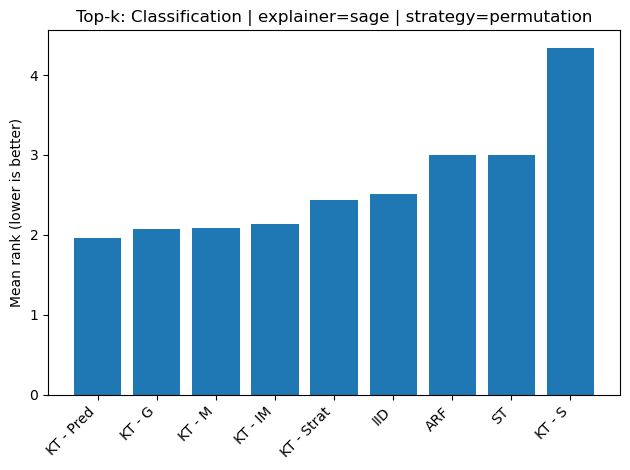

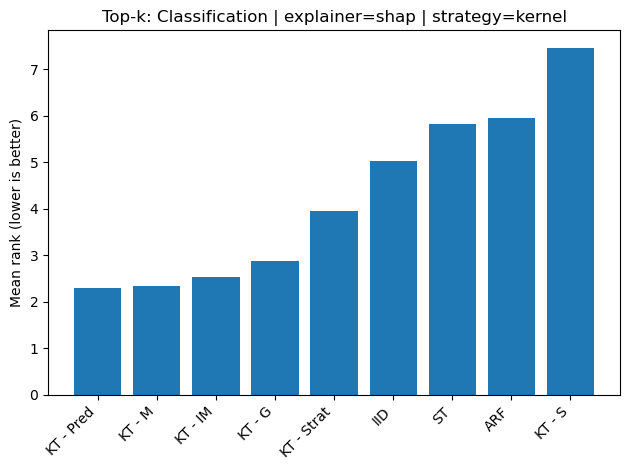

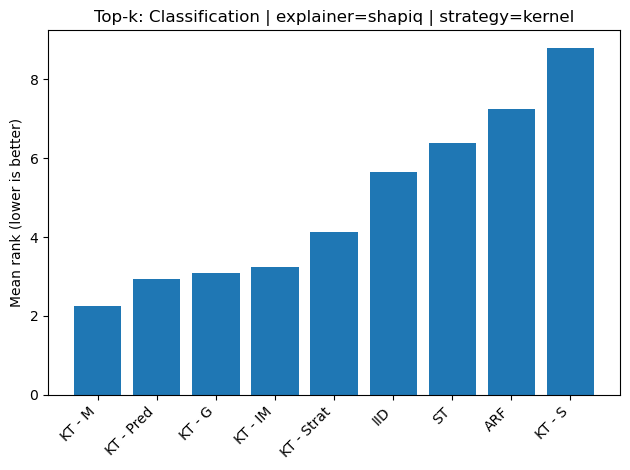

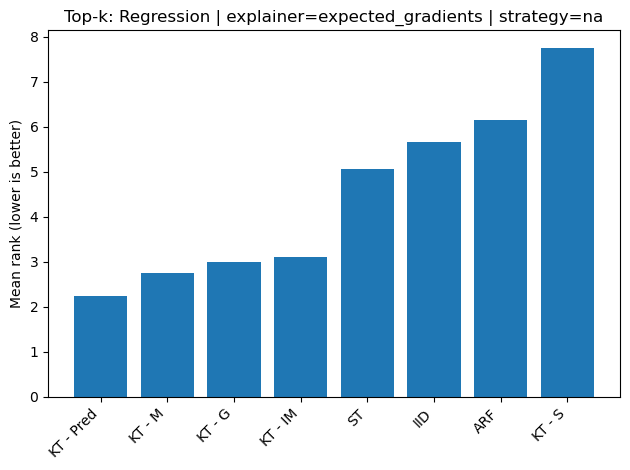

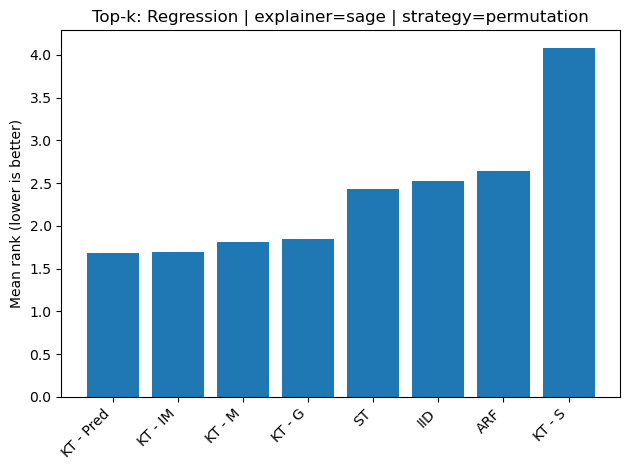

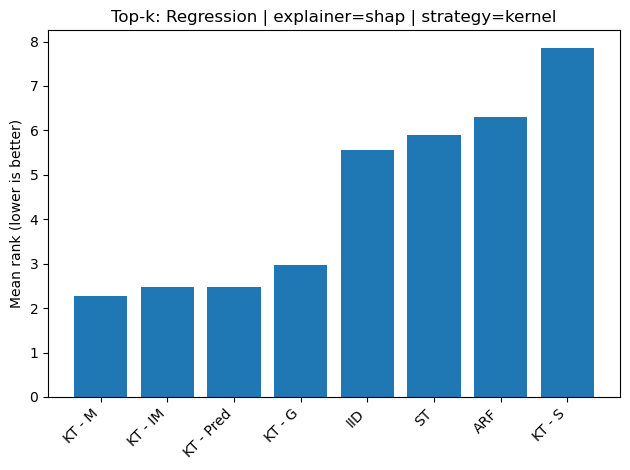

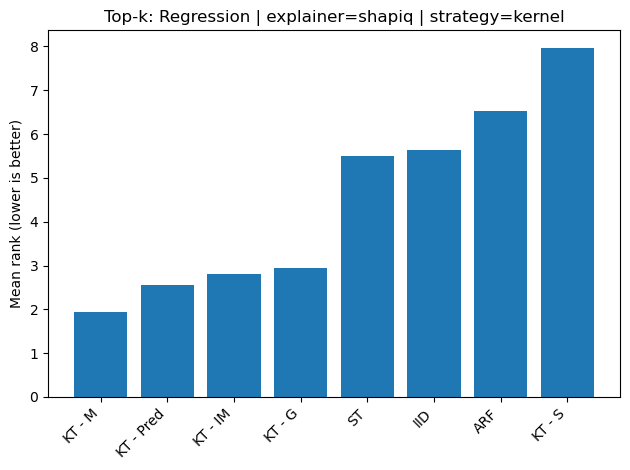

/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_41974/2277959262.py:173: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heat = sub.groupby(["feature_bin", "method"])["rank"].mean().unstack()


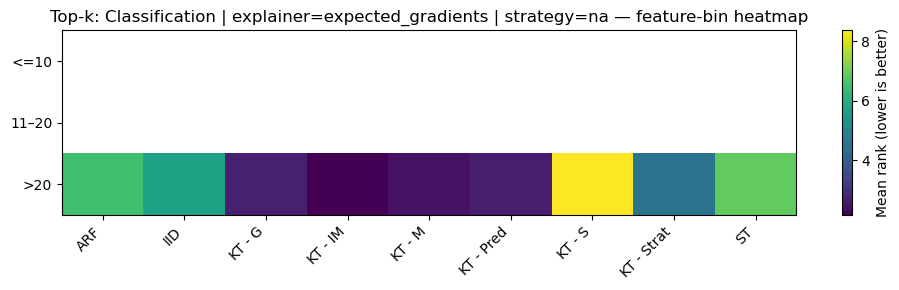

/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_41974/2277959262.py:173: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heat = sub.groupby(["feature_bin", "method"])["rank"].mean().unstack()


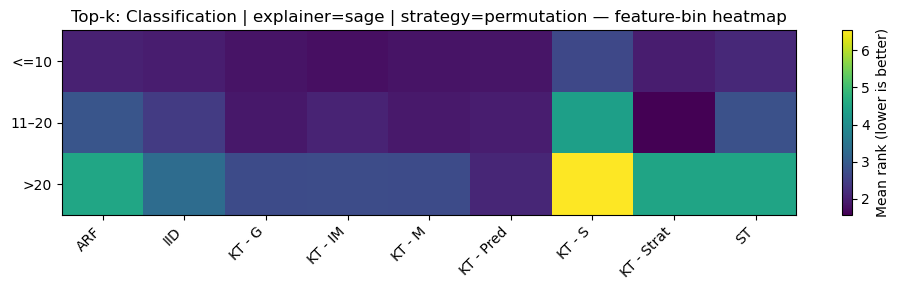

/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_41974/2277959262.py:173: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heat = sub.groupby(["feature_bin", "method"])["rank"].mean().unstack()


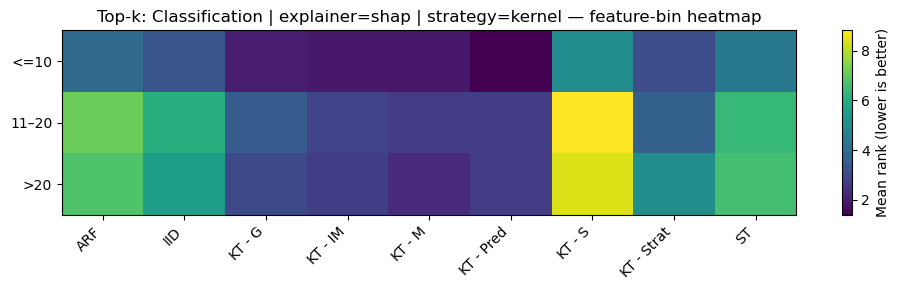

/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_41974/2277959262.py:173: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heat = sub.groupby(["feature_bin", "method"])["rank"].mean().unstack()


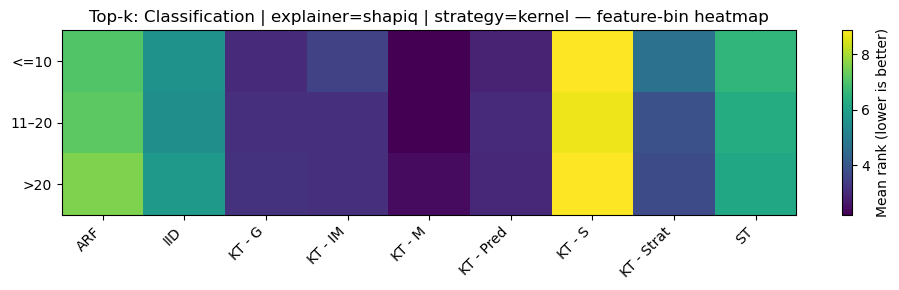

/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_41974/2277959262.py:173: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heat = sub.groupby(["feature_bin", "method"])["rank"].mean().unstack()


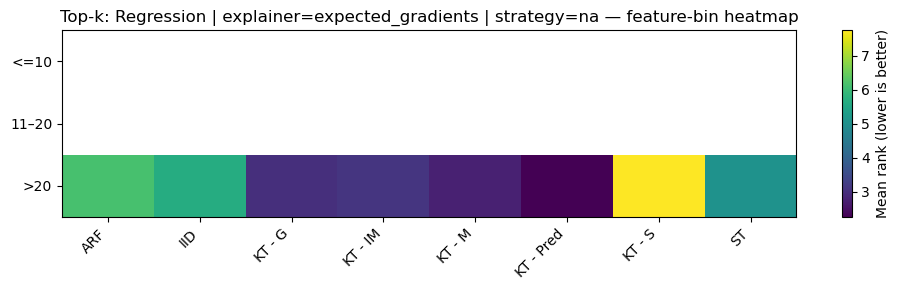

/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_41974/2277959262.py:173: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heat = sub.groupby(["feature_bin", "method"])["rank"].mean().unstack()


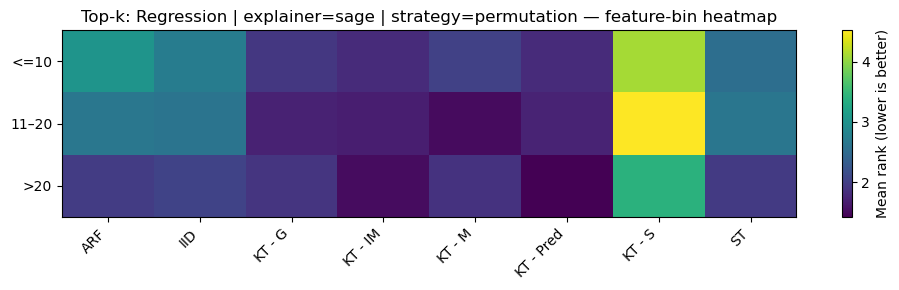

/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_41974/2277959262.py:173: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heat = sub.groupby(["feature_bin", "method"])["rank"].mean().unstack()


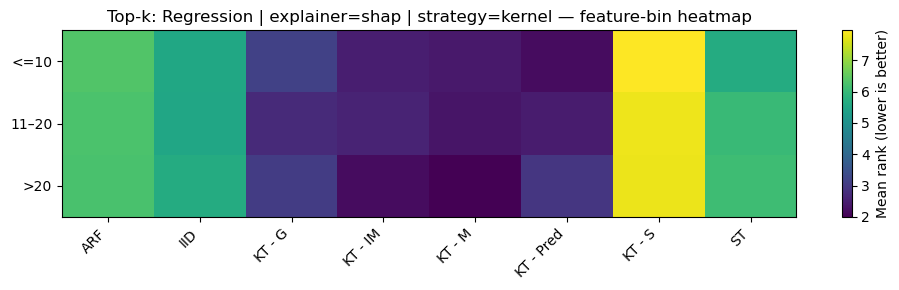

/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_41974/2277959262.py:173: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heat = sub.groupby(["feature_bin", "method"])["rank"].mean().unstack()


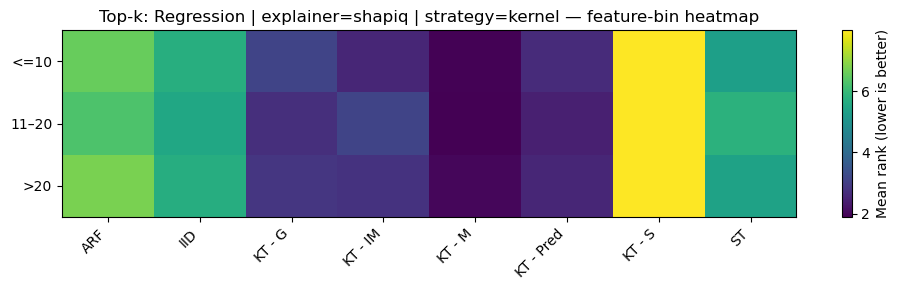

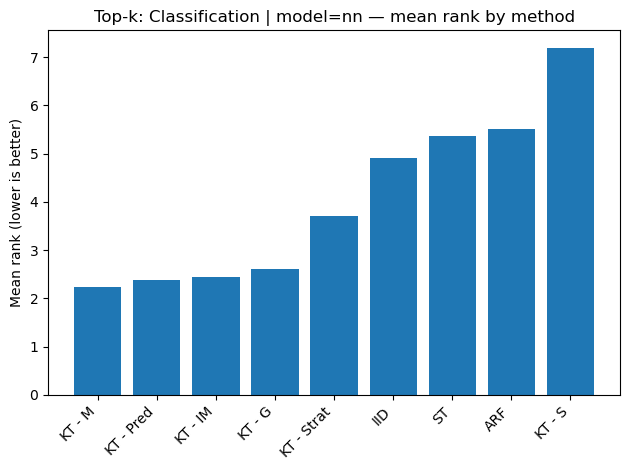

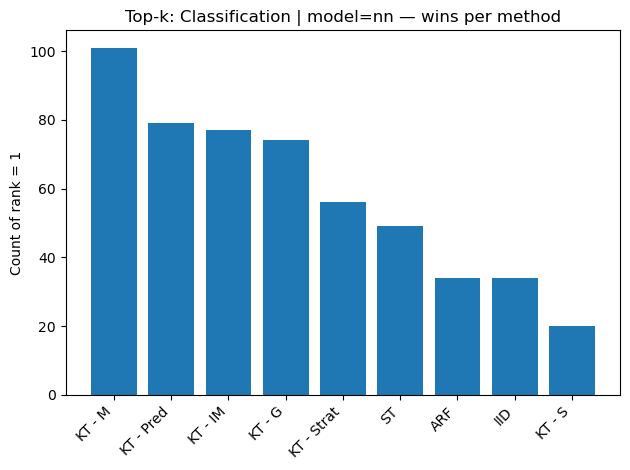

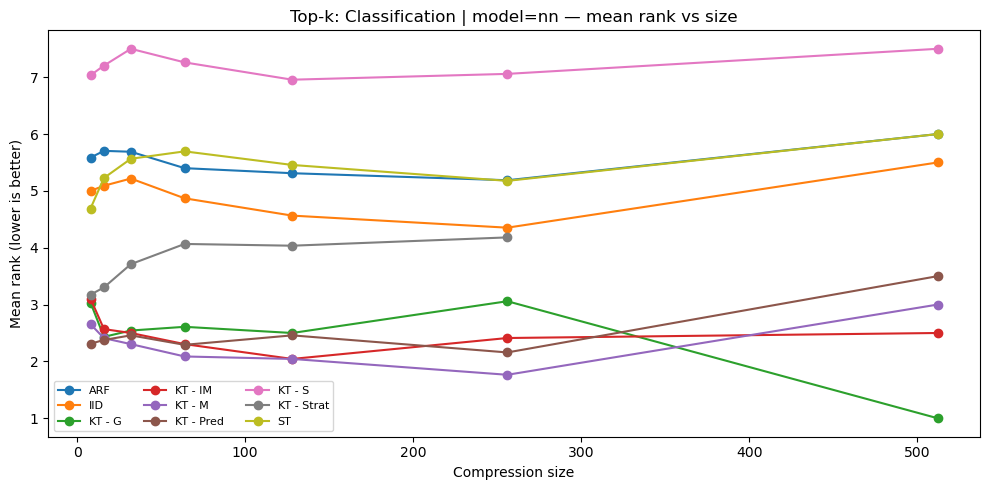

/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_41974/2277959262.py:173: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heat = sub.groupby(["feature_bin", "method"])["rank"].mean().unstack()


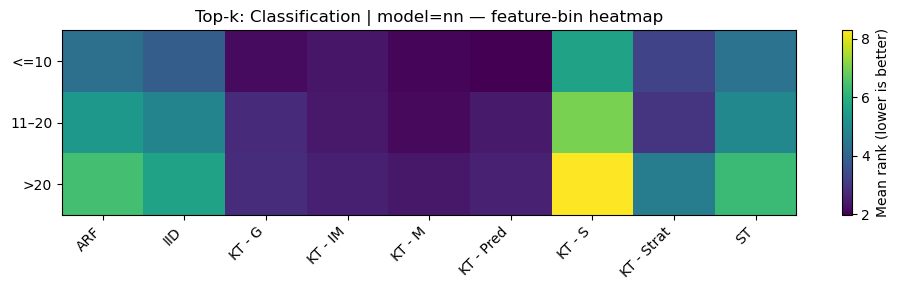

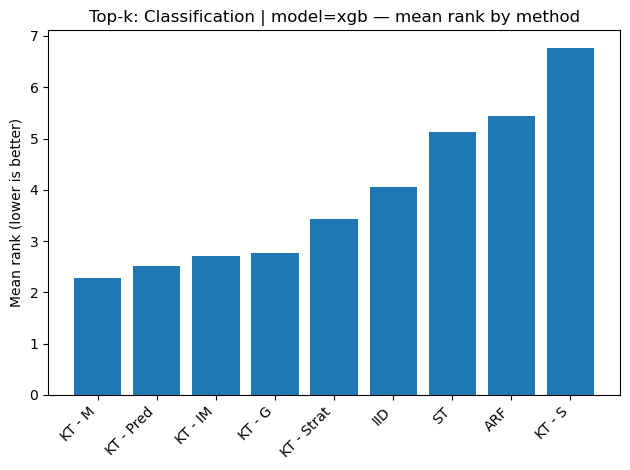

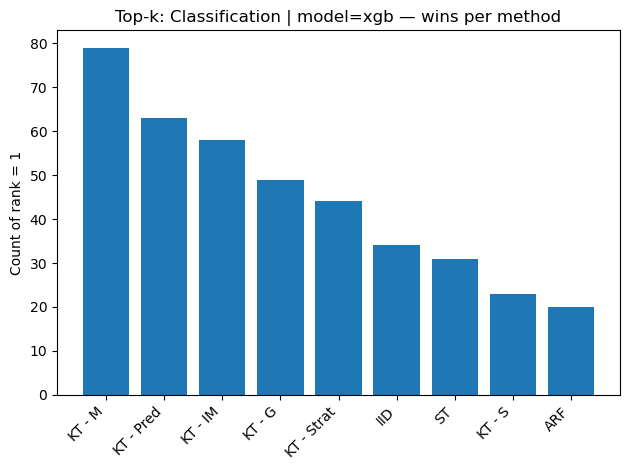

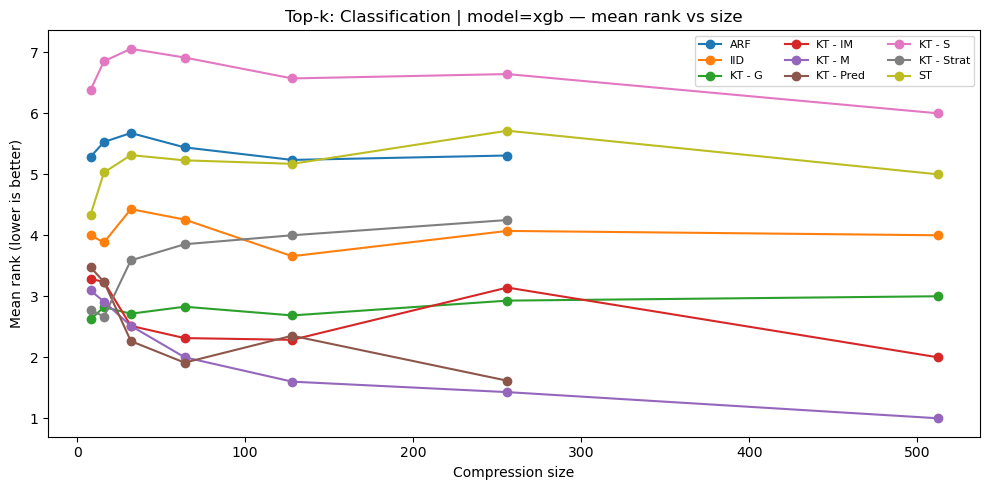

/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_41974/2277959262.py:173: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heat = sub.groupby(["feature_bin", "method"])["rank"].mean().unstack()


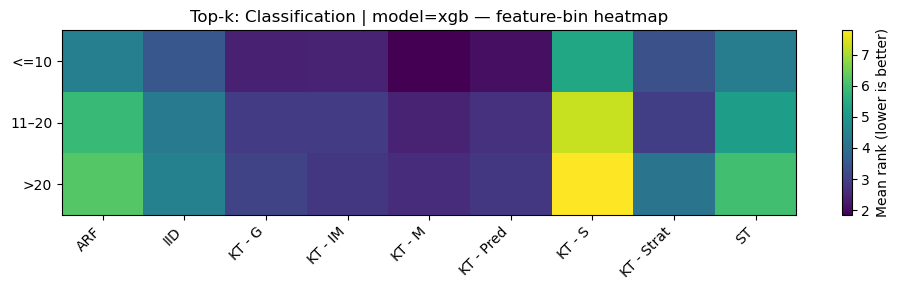

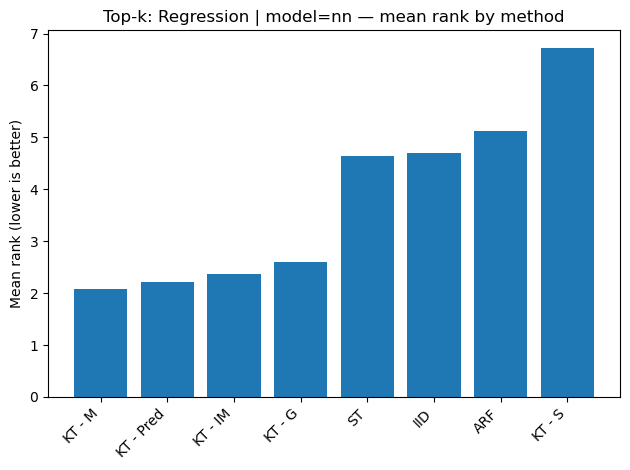

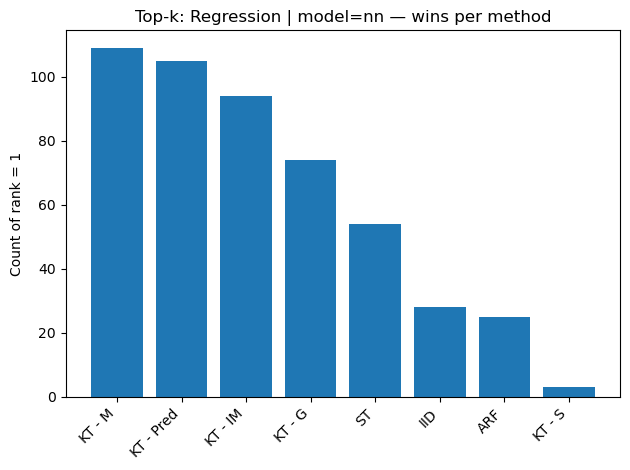

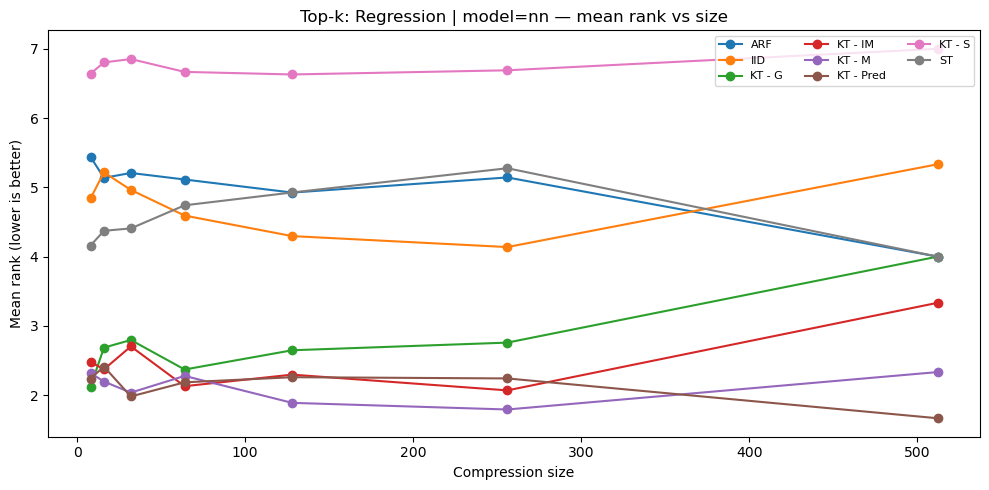

/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_41974/2277959262.py:173: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heat = sub.groupby(["feature_bin", "method"])["rank"].mean().unstack()


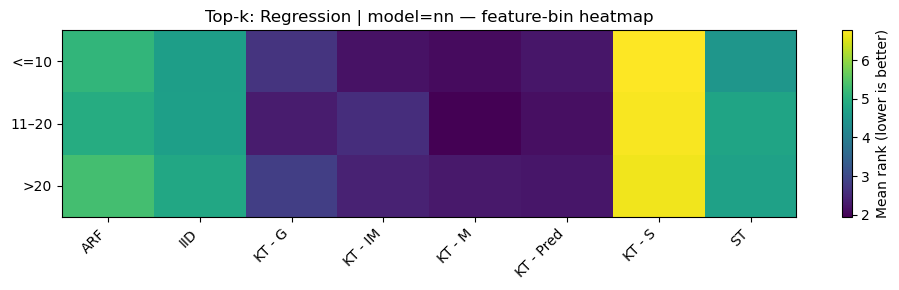

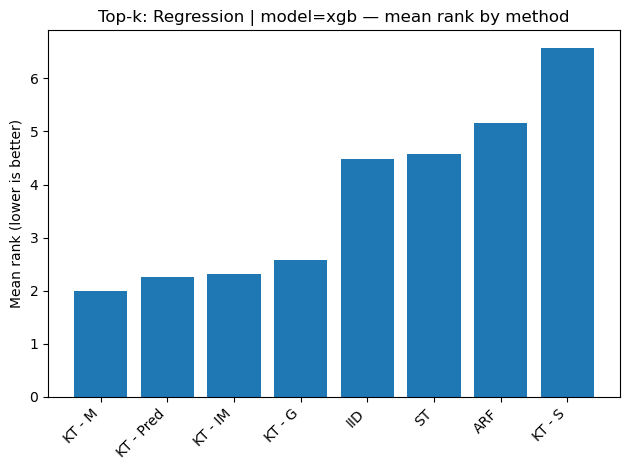

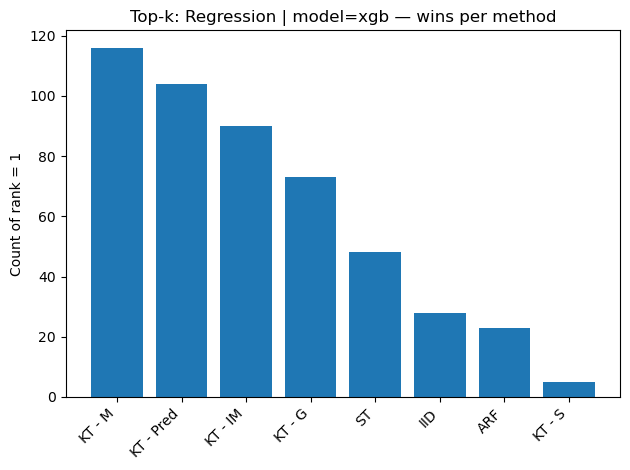

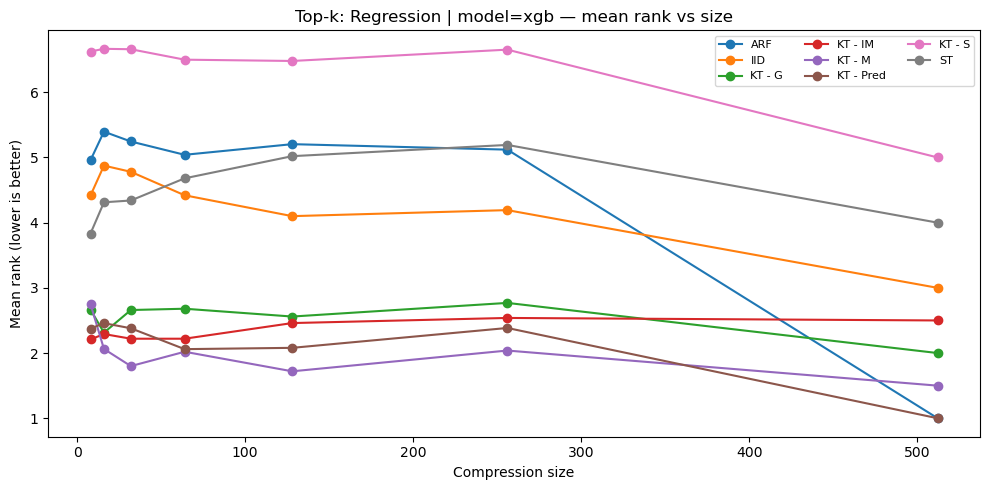

/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_41974/2277959262.py:173: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heat = sub.groupby(["feature_bin", "method"])["rank"].mean().unstack()


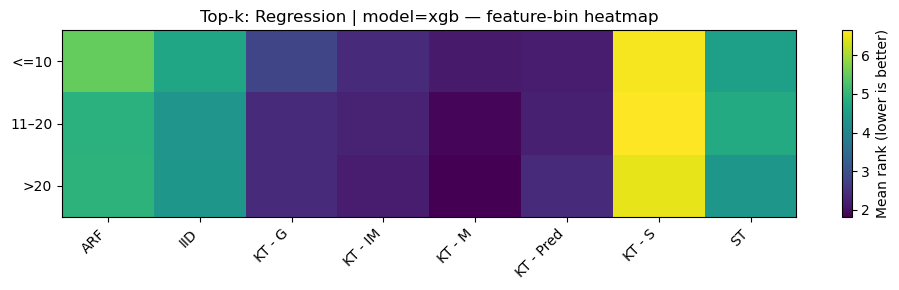


=== BEST METHODS for Top-k (lowest mean rank) ===
Global best: KT - M (mean rank=2.14)
Classification : best=KT - M (mean rank=2.26)
Regression     : best=KT - M (mean rank=2.04)
Classification  | model=nn : best=KT - M (mean rank=2.24)
Classification  | model=xgb: best=KT - M (mean rank=2.28)
Regression      | model=nn : best=KT - M (mean rank=2.09)
Regression      | model=xgb: best=KT - M (mean rank=1.99)

Done. Plots saved to: /Users/milannapahasian_user_account/Documents/UNI/CTE_thesis/bsc-compress-then-explain/bsc-compress-then-explain/package_metadata/plots_rank_analysis


In [4]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# CONFIG
# ----------------------------
CSV_PATH = Path("/Users/milannapahasian_user_account/Documents/UNI/CTE_thesis/bsc-compress-then-explain/bsc-compress-then-explain/package_metadata/summary_table_ranked_edited.csv")

OUT_DIR = Path("/Users/milannapahasian_user_account/Documents/UNI/CTE_thesis/bsc-compress-then-explain/bsc-compress-then-explain/package_metadata/plots_rank_analysis")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Which metrics to run (all are ranks already in your CSV)
METRICS = {
    "mae_": "MAE",
    "mmd_": "MMD",
    "compression_time_": "Compression time",
    "top_k_": "Top-k",
    # optional:
    # "explanation_time_": "Explanation time",
}

# Feature bins for "many features" analysis (yours)
FEATURE_BINS = [-np.inf, 10, 20, np.inf]
FEATURE_LABELS = ["<=10", "11–20", ">20"]

# If you want to reduce plot explosion, you can filter here (set to None to keep all)
FILTER_TYPES = None          # e.g. ["Classification"]
FILTER_EXPLAINERS = None     # e.g. ["sage"]
FILTER_STRATEGIES = None     # e.g. ["permutation"]
FILTER_MODELS = None         # e.g. ["nn"]

# ----------------------------
# LOAD
# ----------------------------
df = pd.read_csv(CSV_PATH)

CONTEXT_COLS = ["dataset", "type", "features", "testsize", "size", "model", "explainer", "strategy"]
missing = [c for c in CONTEXT_COLS if c not in df.columns]
if missing:
    raise ValueError(f"Missing expected context columns: {missing}")

df["features"] = pd.to_numeric(df["features"], errors="coerce")
df["testsize"] = pd.to_numeric(df["testsize"], errors="coerce")
df["size"] = pd.to_numeric(df["size"], errors="coerce")


# ----------------------------
# HELPERS
# ----------------------------
def metric_cols(prefix: str) -> list[str]:
    return [c for c in df.columns if c.startswith(prefix)]

def clean_method_name(col: str, prefix: str) -> str:
    name = col[len(prefix):]
    name = name.replace("_Not needed", "")
    name = name.replace("kernel_thinning_", "KT - ")
    name = name.replace("stein_thinning", "ST")
    name = name.replace("arfpy", "ARF")
    name = name.replace("iid", "IID")
    name = name.replace("gaussian", "G")
    name = name.replace("inverse_multiquadric", "IM")
    name = name.replace("matern", "M")
    name = name.replace("predictions", "Pred")
    name = name.replace("sobolev", "S")
    name = name.replace("stratified", "Strat")
    name = name.replace("_", " ").strip()
    return name

def order_methods(methods: list[str]) -> list[str]:
    preferred = ["ARF", "IID", "KT - G", "KT - IM", "KT - M", "KT - Pred", "KT - S", "KT - Strat", "ST"]
    ordered = [m for m in preferred if m in methods]
    ordered += [m for m in sorted(set(methods)) if m not in ordered]
    return ordered

def melt_metric(prefix: str) -> pd.DataFrame:
    cols = metric_cols(prefix)
    if not cols:
        raise ValueError(f"No columns found with prefix '{prefix}'")

    long = df.melt(
        id_vars=CONTEXT_COLS,
        value_vars=cols,
        var_name="method_raw",
        value_name="rank",
    )
    long["method"] = long["method_raw"].apply(lambda c: clean_method_name(c, prefix))
    long["rank"] = pd.to_numeric(long["rank"], errors="coerce")
    long = long.dropna(subset=["rank", "size", "features"])

    # Feature bins
    long["feature_bin"] = pd.cut(long["features"], bins=FEATURE_BINS, labels=FEATURE_LABELS)

    return long

def savefig(name: str):
    plt.savefig(OUT_DIR / f"{name}.png", dpi=200, bbox_inches="tight")

def safe(s: str) -> str:
    return str(s).replace(" ", "_").replace("/", "_").replace(":", "_")

def apply_filters(long: pd.DataFrame) -> pd.DataFrame:
    out = long
    if FILTER_TYPES is not None:
        out = out[out["type"].isin(FILTER_TYPES)]
    if FILTER_EXPLAINERS is not None:
        out = out[out["explainer"].isin(FILTER_EXPLAINERS)]
    if FILTER_STRATEGIES is not None:
        out = out[out["strategy"].isin(FILTER_STRATEGIES)]
    if FILTER_MODELS is not None:
        out = out[out["model"].isin(FILTER_MODELS)]
    return out

def plot_mean_rank_bar(sub: pd.DataFrame, title: str, fname: str):
    mr = sub.groupby("method")["rank"].mean().sort_values()
    plt.figure()
    plt.bar(mr.index, mr.values)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Mean rank (lower is better)")
    plt.title(title)
    plt.tight_layout()
    savefig(fname)
    plt.show()

def plot_wins_bar(sub: pd.DataFrame, title: str, fname: str):
    wins = (sub["rank"] == 1).groupby(sub["method"]).sum().sort_values(ascending=False)
    plt.figure()
    plt.bar(wins.index, wins.values)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Count of rank = 1")
    plt.title(title)
    plt.tight_layout()
    savefig(fname)
    plt.show()

def plot_rank_distribution_stacked(sub: pd.DataFrame, title: str, fname: str):
    dist = sub.groupby(["method", "rank"]).size().unstack(fill_value=0)
    dist_prop = dist.div(dist.sum(axis=1), axis=0)
    dist_prop = dist_prop.loc[order_methods(dist_prop.index.tolist())]

    plt.figure(figsize=(10, 5))
    bottom = np.zeros(len(dist_prop))
    for r in sorted(dist_prop.columns):
        vals = dist_prop[r].values
        plt.bar(dist_prop.index, vals, bottom=bottom, label=f"rank {int(r)}")
        bottom += vals
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Proportion")
    plt.title(title)
    plt.legend(ncol=3, fontsize=8)
    plt.tight_layout()
    savefig(fname)
    plt.show()

def plot_rank_vs_size(sub: pd.DataFrame, title: str, fname: str):
    curve = sub.groupby(["method", "size"])["rank"].mean().reset_index().sort_values(["method", "size"])
    plt.figure(figsize=(10, 5))
    for method in order_methods(curve["method"].unique().tolist()):
        msub = curve[curve["method"] == method]
        if msub.empty:
            continue
        plt.plot(msub["size"], msub["rank"], marker="o", label=method)
    plt.xlabel("Compression size")
    plt.ylabel("Mean rank (lower is better)")
    plt.title(title)
    plt.legend(ncol=3, fontsize=8)
    plt.tight_layout()
    savefig(fname)
    plt.show()

def plot_feature_heatmap(sub: pd.DataFrame, title: str, fname: str):
    heat = sub.groupby(["feature_bin", "method"])["rank"].mean().unstack()
    heat = heat.reindex(columns=order_methods(heat.columns.tolist()))

    plt.figure(figsize=(10, 3))
    plt.imshow(heat.values, aspect="auto")
    plt.yticks(range(len(heat.index)), heat.index.astype(str))
    plt.xticks(range(len(heat.columns)), heat.columns, rotation=45, ha="right")
    plt.colorbar(label="Mean rank (lower is better)")
    plt.title(title)
    plt.tight_layout()
    savefig(fname)
    plt.show()


# ----------------------------
# RUN ALL PLOTS FOR EACH METRIC
# ----------------------------
for prefix, metric_title in METRICS.items():
    long = melt_metric(prefix)
    long = apply_filters(long)

    # Determine available levels after filtering
    types = sorted(long["type"].dropna().unique())
    explainers = sorted(long["explainer"].dropna().unique())
    strategies = sorted(long["strategy"].dropna().unique())
    models = sorted(long["model"].dropna().unique())

    # ---- GLOBAL PLOTS ----
    plot_mean_rank_bar(
        long,
        title=f"Global {metric_title}: mean rank across all configurations",
        fname=f"{prefix[:-1]}_01_global_mean_rank"
    )

    plot_wins_bar(
        long,
        title=f"Global {metric_title}: wins per method (rank=1)",
        fname=f"{prefix[:-1]}_02_global_wins"
    )

    plot_rank_distribution_stacked(
        long,
        title=f"Global {metric_title}: rank distribution per method",
        fname=f"{prefix[:-1]}_03_global_rank_distribution"
    )

    plot_rank_vs_size(
        long,
        title=f"Global {metric_title}: mean rank vs compression size",
        fname=f"{prefix[:-1]}_04_global_rank_vs_size"
    )

    plot_feature_heatmap(
        long,
        title=f"Global {metric_title}: mean rank by feature dimensionality",
        fname=f"{prefix[:-1]}_05_global_feature_heatmap"
    )

    # ---- CONDITIONAL: type × explainer × strategy ----
    # Mean rank barplot
    for task in types:
        for expl in explainers:
            for strat in strategies:
                sub = long[(long["type"] == task) & (long["explainer"] == expl) & (long["strategy"] == strat)]
                if sub.empty:
                    continue
                plot_mean_rank_bar(
                    sub,
                    title=f"{metric_title}: {task} | explainer={expl} | strategy={strat}",
                    fname=f"{prefix[:-1]}_06_meanrank_type_{safe(task)}_expl_{safe(expl)}_strat_{safe(strat)}"
                )

    # Feature-bin heatmap
    for task in types:
        for expl in explainers:
            for strat in strategies:
                sub = long[(long["type"] == task) & (long["explainer"] == expl) & (long["strategy"] == strat)]
                if sub.empty:
                    continue
                plot_feature_heatmap(
                    sub,
                    title=f"{metric_title}: {task} | explainer={expl} | strategy={strat} — feature-bin heatmap",
                    fname=f"{prefix[:-1]}_07_heatmap_type_{safe(task)}_expl_{safe(expl)}_strat_{safe(strat)}"
                )

    # ---- CONDITIONAL: type × model (keeps model analysis) ----
    for task in types:
        for model in models:
            sub = long[(long["type"] == task) & (long["model"] == model)]
            if sub.empty:
                continue

            plot_mean_rank_bar(
                sub,
                title=f"{metric_title}: {task} | model={model} — mean rank by method",
                fname=f"{prefix[:-1]}_08_meanrank_type_{safe(task)}_model_{safe(model)}"
            )

            plot_wins_bar(
                sub,
                title=f"{metric_title}: {task} | model={model} — wins per method",
                fname=f"{prefix[:-1]}_09_wins_type_{safe(task)}_model_{safe(model)}"
            )

            plot_rank_vs_size(
                sub,
                title=f"{metric_title}: {task} | model={model} — mean rank vs size",
                fname=f"{prefix[:-1]}_10_rank_vs_size_type_{safe(task)}_model_{safe(model)}"
            )

            plot_feature_heatmap(
                sub,
                title=f"{metric_title}: {task} | model={model} — feature-bin heatmap",
                fname=f"{prefix[:-1]}_11_heatmap_type_{safe(task)}_model_{safe(model)}"
            )

    # ---- OPTIONAL: print best method summaries (nice for writing conclusions) ----
    print(f"\n=== BEST METHODS for {metric_title} (lowest mean rank) ===")
    # global
    global_mr = long.groupby("method")["rank"].mean().sort_values()
    if not global_mr.empty:
        print(f"Global best: {global_mr.index[0]} (mean rank={global_mr.iloc[0]:.2f})")

    # by type
    for task in types:
        sub = long[long["type"] == task]
        mr = sub.groupby("method")["rank"].mean().sort_values()
        if not mr.empty:
            print(f"{task:15s}: best={mr.index[0]} (mean rank={mr.iloc[0]:.2f})")

    # by type × model
    for task in types:
        for model in models:
            sub = long[(long["type"] == task) & (long["model"] == model)]
            mr = sub.groupby("method")["rank"].mean().sort_values()
            if not mr.empty:
                print(f"{task:15s} | model={model:3s}: best={mr.index[0]} (mean rank={mr.iloc[0]:.2f})")

print(f"\nDone. Plots saved to: {OUT_DIR}")